# Simulaciones: Uso estratégico del modelo MINCIENCIAS en IES colombianas

> **Artículo científico en desarrollo**
>
> *"El modelo de medición de MINCIENCIAS cumple una función legítima de clasificación
> y seguimiento del sistema nacional de CTI; sin embargo, su adopción como eje
> estratégico de gestión investigativa dentro de las IES produce una confusión entre
> capacidad de producción, calidad científica y misión institucional, generando
> incentivos perversos y decisiones subóptimas."*

---

## Estructura del notebook

| Sección | Contenido |
|---|---|
| **0. Configuración** | Librerías, estilos y parámetros globales |
| **1. Motor del modelo** | 169 productos oficiales — Convocatoria 954 / Minciencias 2024 |
| **2. Verificación** | Validación contra el modelo oficial |
| **S1. Mapa de valor** | Contribución marginal de todos los productos |
| **S2. Caso EC_A** | El mismo esfuerzo, diferente valor entre modelos |
| **S3. Rendimientos decrecientes** | La función λ y el techo invisible |
| **S4. Trampa del libro** | Movilidad categorial y gestión de visibilidad |

**Modelo:** M601PR04G01 — Convocatoria 954 — Minciencias 2024
**Cobertura:** 169/169 productos oficiales


## 0. Instalación y configuración

In [ ]:
!pip install matplotlib numpy pandas --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130,
})

COLORES = {
    'TOP':'#1a3a5c', 'A':'#2e7d9f', 'B':'#7fb3c8',
    'ASC':'#2d6a4f', 'DPC':'#74c69d',
    'FRHA':'#b5451b', 'FRHB':'#e08d6e',
    'acento':'#e63946', 'fondo':'#f8f9fa',
}
EDAD_GRUPO = 10
print("✓ Configuración lista.")


✓ Configuración lista.


## 1. Motor del modelo Minciencias 2024

### Fórmula del Indicador de Grupo (M601PR04G01)

$$IndGrupo = 3.7 \cdot Nc_{TOP} + 2.3 \cdot Nc_A + 0.4 \cdot Nc_B
+ 1.5 \cdot ASC + 0.5 \cdot DPC + 1.0 \cdot FRH_A + 0.2 \cdot FRH_B$$

### Normalización logarítmica λ

$$\lambda_{subtipo} = \ln\left(\frac{N_{productos}}{\min(edad, ventana)} + 1\right)$$

> **Propiedad clave:** La pendiente de ln(x) decrece con x → rendimientos marginales decrecientes por diseño.


In [ ]:
# ── Pesos de calidad ─────────────────────────────────────────
CALIDAD_PESO = {
    'TOP':  3.7,   # Artículos Q1, patentes obtenidas, libros Q1
    'A':    2.3,   # Artículos Q2-Q3, libros Q3, diseños
    'B':    0.4,   # Artículos sin cuartil, notas, libros sin Q
    'ASC':  1.5,   # Apropiación Social del Conocimiento
    'DPC':  0.5,   # Divulgación Pública de la Ciencia
    'FRHA': 1.0,   # FRH Tipo A — tesis doctorales, asesorías posdoctorales
    'FRHB': 0.2,   # FRH Tipo B — maestrías, proyectos, pregrados
}

# ── Catálogo completo: 169 productos oficiales ───────────────
# Fuente: Convocatoria 954 / Modelo M601PR04G01 / Minciencias 2024
# Columnas: código, nombre, clase, calidad,
#           peso_relativo, peso_alta_calidad, ventana_obs (años)

PRODUCTOS = pd.DataFrame([
    ('ART_OPEN_A1', 'Artículo open access Q1', 'GNC', 'TOP', 10.0, 100, 7),
    ('ART_OPEN_A2', 'Artículo open access Q2', 'GNC', 'TOP', 6.0, 100, 7),
    ('ART_OPEN_B', 'Artículo open access Q3', 'GNC', 'A', 3.5, 100, 7),
    ('ART_OPEN_C', 'Artículo open access Q4', 'GNC', 'A', 2.0, 100, 7),
    ('ART_OPEN_D', 'Artículo open access sin cuartil', 'GNC', 'B', 10.0, 5, 7),
    ('ART_A1', 'Artículo de investigación Q1', 'GNC', 'TOP', 9.5, 100, 7),
    ('ART_A2', 'Artículo de investigación Q2', 'GNC', 'TOP', 5.5, 100, 7),
    ('ART_B', 'Artículo de investigación Q3', 'GNC', 'A', 3.0, 100, 7),
    ('ART_C', 'Artículo de investigación Q4', 'GNC', 'A', 1.5, 100, 7),
    ('ART_D', 'Artículo de investigación sin Q', 'GNC', 'B', 9.0, 5, 7),
    ('N_A1', 'Nota científica Q1', 'GNC', 'B', 10.0, 5, 7),
    ('N_A2', 'Nota científica Q2', 'GNC', 'B', 8.5, 5, 7),
    ('N_B', 'Nota científica Q3', 'GNC', 'B', 6.0, 5, 7),
    ('N_C', 'Nota científica Q4', 'GNC', 'B', 4.0, 5, 7),
    ('N_D', 'Nota científica sin cuartil', 'GNC', 'B', 2.0, 5, 5),
    ('LIB_A1', 'Libro resultado investigación Q1', 'GNC', 'TOP', 10.0, 300, 7),
    ('LIB_A', 'Libro resultado investigación Q2', 'GNC', 'TOP', 9.0, 300, 7),
    ('LIB_B', 'Libro resultado investigación Q3', 'GNC', 'A', 8.0, 300, 7),
    ('LIB_C', 'Libro resultado investigación s/Q', 'GNC', 'B', 10.0, 15, 7),
    ('CAP_LIB_A1', 'Capítulo de libro Q1', 'GNC', 'TOP', 10.0, 60, 5),
    ('CAP_LIB_A', 'Capítulo de libro Q2', 'GNC', 'TOP', 9.0, 60, 5),
    ('CAP_LIB_B', 'Capítulo de libro Q3', 'GNC', 'A', 8.0, 60, 5),
    ('CAP_LIB_C', 'Capítulo de libro sin cuartil', 'GNC', 'B', 10.0, 3, 5),
    ('LIB_FOR1', 'Libro de formación Q1', 'GNC', 'B', 10.0, 60, 7),
    ('P_A1', 'Patente invención obtenida intl.', 'GNC', 'TOP', 10.0, 500, 10),
    ('P_A2', 'Patente invención obtenida nac.', 'GNC', 'TOP', 7.0, 500, 10),
    ('P_A3', 'Patente invención trámite intl.', 'GNC', 'A', 6.0, 500, 10),
    ('P_A4', 'Patente invención trámite nac.', 'GNC', 'A', 5.5, 500, 10),
    ('P_B1', 'Patente invención B1', 'GNC', 'B', 5.0, 500, 10),
    ('P_B2', 'Patente invención B2', 'GNC', 'B', 3.5, 500, 10),
    ('P_B3', 'Patente invención B3', 'GNC', 'B', 3.0, 500, 10),
    ('P_B4', 'Patente invención B4', 'GNC', 'B', 2.6, 500, 10),
    ('P_B5', 'Patente invención B5', 'GNC', 'B', 2.5, 500, 10),
    ('P_C', 'Patente invención C', 'GNC', 'B', 1.8, 500, 10),
    ('M_A1', 'Modelo utilidad obtenido intl.', 'GNC', 'TOP', 6.0, 500, 10),
    ('M_A2', 'Modelo utilidad obtenido nac.', 'GNC', 'TOP', 4.2, 500, 10),
    ('M_A3', 'Modelo utilidad trámite intl.', 'GNC', 'A', 3.6, 500, 10),
    ('M_A4', 'Modelo utilidad trámite nac.', 'GNC', 'A', 3.33, 500, 10),
    ('M_B1', 'Modelo utilidad B1', 'GNC', 'B', 3.0, 500, 10),
    ('M_B2', 'Modelo utilidad B2', 'GNC', 'B', 2.1, 500, 10),
    ('M_B3', 'Modelo utilidad B3', 'GNC', 'B', 1.8, 500, 10),
    ('M_B4', 'Modelo utilidad B4', 'GNC', 'B', 1.7, 500, 10),
    ('M_B5', 'Modelo utilidad B5', 'GNC', 'B', 1.5, 500, 10),
    ('M_C', 'Modelo utilidad C', 'GNC', 'B', 1.1, 500, 10),
    ('VV_A1', 'Variedad vegetal A1', 'GNC', 'TOP', 10.0, 300, 10),
    ('VV_A2', 'Variedad vegetal A2', 'GNC', 'TOP', 8.0, 300, 10),
    ('VV_A3', 'Variedad vegetal A3', 'GNC', 'A', 5.0, 300, 10),
    ('VV_A4', 'Variedad vegetal A4', 'GNC', 'A', 2.5, 300, 10),
    ('VV_B1', 'Variedad vegetal B1', 'GNC', 'B', 5.0, 300, 10),
    ('VV_B2', 'Variedad vegetal B2', 'GNC', 'B', 4.0, 300, 10),
    ('VV_B3', 'Variedad vegetal B3', 'GNC', 'B', 2.5, 300, 10),
    ('VV_B4', 'Variedad vegetal B4', 'GNC', 'B', 1.0, 300, 10),
    ('VA_A', 'Nueva raza animal', 'GNC', 'TOP', 10.0, 300, 10),
    ('VA_B', 'Población mejorada razas pecuarias', 'GNC', 'A', 5.0, 300, 10),
    ('AAD_A1', 'Invest-Creación AAD A1', 'GNC', 'TOP', 10.0, 100, 10),
    ('AAD_A', 'Invest-Creación AAD A', 'GNC', 'TOP', 8.0, 100, 10),
    ('AAD_B', 'Invest-Creación AAD B', 'GNC', 'A', 6.0, 100, 10),
    ('AAD_C', 'Invest-Creación AAD C', 'GNC', 'B', 4.0, 100, 10),
    ('DI_A', 'Diseño industrial registrado', 'DTI', 'A', 10.0, 35, 5),
    ('DI_B', 'Diseño industrial en trámite', 'DTI', 'B', 5.0, 35, 5),
    ('ECI', 'Esquema circuito integrado', 'DTI', 'A', 4.0, 35, 5),
    ('SF', 'Software registrado', 'DTI', 'B', 8.0, 35, 5),
    ('PP', 'Planta piloto', 'DTI', 'A', 4.0, 35, 5),
    ('PI', 'Prototipo industrial', 'DTI', 'A', 4.0, 35, 5),
    ('SD', 'Signo distintivo', 'DTI', 'A', 4.0, 35, 5),
    ('PN', 'Producto nutracéutico', 'DTI', 'B', 6.0, 35, 5),
    ('CC', 'Colección científica', 'DTI', 'B', 10.0, 35, 5),
    ('NRC_A', 'Nuevo registro científico A', 'DTI', 'B', 8.0, 35, 5),
    ('NRC_B', 'Nuevo registro científico B', 'DTI', 'B', 5.0, 35, 5),
    ('SE', 'Secreto empresarial', 'DTI', 'A', 5.0, 100, 5),
    ('EBT_A', 'Empresa base tecnológica A', 'DTI', 'A', 10.0, 100, 5),
    ('EBT_B', 'Empresa base tecnológica B', 'DTI', 'B', 8.0, 100, 5),
    ('ICC_A', 'Empresa creativa y cultural A', 'DTI', 'A', 10.0, 100, 5),
    ('ICC_B', 'Empresa creativa y cultural B', 'DTI', 'B', 4.0, 100, 5),
    ('IG_A1', 'Innovación gestión empresarial A1', 'DTI', 'A', 10.0, 100, 5),
    ('IG_A2', 'Innovación gestión empresarial A2', 'DTI', 'A', 6.0, 100, 5),
    ('IG_B1', 'Innovación gestión empresarial B1', 'DTI', 'B', 5.0, 100, 5),
    ('IG_B2', 'Innovación gestión empresarial B2', 'DTI', 'B', 3.0, 100, 5),
    ('IPP', 'Innovación procedimientos/serv.', 'DTI', 'B', 5.0, 100, 5),
    ('RNL_A', 'Regulación/norma/legislación A', 'DTI', 'TOP', 10.0, 100, 5),
    ('RNL_B', 'Regulación/norma/legislación B', 'DTI', 'A', 8.0, 100, 5),
    ('RNR', 'Normatividad espectro radioeléct.', 'DTI', 'A', 8.0, 100, 5),
    ('RNT', 'Norma técnica', 'DTI', 'B', 7.0, 100, 5),
    ('RNPC', 'Guía práctica clínica', 'DTI', 'B', 7.0, 100, 5),
    ('GMCF', 'Guía manejo clínico forense', 'DTI', 'B', 7.0, 100, 5),
    ('MADV', 'Manual atención víctimas', 'DTI', 'B', 7.0, 100, 5),
    ('PAU', 'Protocolo atención usuarios', 'DTI', 'B', 7.0, 100, 5),
    ('PVE', 'Protocolo vigilancia epidemiol.', 'DTI', 'B', 7.0, 100, 5),
    ('AL', 'Acuerdo de Ley', 'DTI', 'B', 8.0, 100, 5),
    ('RNPL', 'Proyecto de Ley', 'DTI', 'B', 6.0, 100, 5),
    ('CT', 'Concepto técnico', 'DTI', 'B', 10.0, 15, 5),
    ('MR', 'Acuerdo licencia I+C', 'DTI', 'B', 10.0, 14, 5),
    ('FIS', 'Formación e ideación social', 'ASC', 'ASC', 10.0, 200, 5),
    ('GPP_A', 'Gen. participación pública A', 'ASC', 'ASC', 10.0, 200, 5),
    ('GPP_B', 'Gen. participación pública B', 'ASC', 'ASC', 7.0, 200, 5),
    ('GPP_C', 'Gen. participación pública C', 'ASC', 'ASC', 5.0, 200, 5),
    ('FCP_A', 'Form. cadenas productivas A', 'ASC', 'ASC', 10.0, 200, 5),
    ('FCP_B', 'Form. cadenas productivas B', 'ASC', 'ASC', 5.0, 200, 5),
    ('FCP_C', 'Form. cadenas productivas C', 'ASC', 'ASC', 3.0, 200, 5),
    ('TCCG_A', 'Transfer. conocim. científico A', 'ASC', 'ASC', 10.0, 200, 5),
    ('TCCG_B', 'Transfer. conocim. científico B', 'ASC', 'ASC', 7.0, 200, 5),
    ('TCCG_C', 'Transfer. conocim. científico C', 'ASC', 'ASC', 4.0, 200, 5),
    ('TCCG_D', 'Transfer. conocim. científico D', 'ASC', 'ASC', 1.0, 200, 5),
    ('EC_A', 'Evento científico tipo A', 'DPC', 'DPC', 10.0, 100, 5),
    ('EC_B', 'Evento científico tipo B', 'DPC', 'DPC', 6.0, 100, 5),
    ('RC_A', 'Red de conocimiento A', 'DPC', 'DPC', 10.0, 100, 5),
    ('RC_B', 'Red de conocimiento B', 'DPC', 'DPC', 6.0, 100, 5),
    ('TC_A', 'Taller de creación A', 'DPC', 'DPC', 10.0, 100, 5),
    ('TC_B', 'Taller de creación B', 'DPC', 'DPC', 8.0, 100, 5),
    ('TC_C', 'Taller de creación C', 'DPC', 'DPC', 6.0, 100, 5),
    ('ECA_A', 'Evento artístico/arq./diseño A', 'DPC', 'DPC', 8.0, 100, 5),
    ('ECA_B', 'Evento artístico/arq./diseño B', 'DPC', 'DPC', 6.0, 100, 5),
    ('WP', 'Working paper', 'DPC', 'DPC', 10.0, 100, 5),
    ('NSG', 'Nueva secuencia genética', 'DPC', 'DPC', 10.0, 100, 5),
    ('ERL', 'Edición revista/libro divulgación', 'DPC', 'DPC', 6.0, 100, 5),
    ('IFI', 'Informe final de investigación', 'DPC', 'DPC', 2.0, 100, 5),
    ('INF', 'Informe técnico', 'DPC', 'DPC', 5.0, 100, 5),
    ('CON_CT', 'Consultoría científico-tecnológ.', 'DPC', 'DPC', 7.5, 100, 5),
    ('CON_AAD', 'Consultoría arte/arq./diseño', 'DPC', 'DPC', 7.5, 100, 5),
    ('PEE_A1', 'Publicación editorial nac. A1', 'DPC', 'DPC', 10.0, 100, 5),
    ('PEE_A2', 'Publicación editorial nac. A2', 'DPC', 'DPC', 8.0, 100, 5),
    ('PEE_B1', 'Publicación editorial reg. B1', 'DPC', 'DPC', 7.0, 100, 5),
    ('PEE_B2', 'Publicación editorial reg. B2', 'DPC', 'DPC', 5.0, 100, 5),
    ('PEE_C1', 'Publicación editorial loc. C1', 'DPC', 'DPC', 5.0, 100, 5),
    ('PEE_C2', 'Publicación editorial loc. C2', 'DPC', 'DPC', 3.0, 100, 5),
    ('PCD_A1', 'Producción contenido digital A1', 'DPC', 'DPC', 10.0, 100, 5),
    ('PCD_A2', 'Producción contenido digital A2', 'DPC', 'DPC', 8.0, 100, 5),
    ('PCD_B1', 'Producción contenido digital B1', 'DPC', 'DPC', 7.0, 100, 5),
    ('PCD_B2', 'Producción contenido digital B2', 'DPC', 'DPC', 5.0, 100, 5),
    ('PCD_C1', 'Producción contenido digital C1', 'DPC', 'DPC', 5.0, 100, 5),
    ('PCD_C2', 'Producción contenido digital C2', 'DPC', 'DPC', 3.0, 100, 5),
    ('TRM_A1', 'Producción transmedia A1', 'DPC', 'DPC', 10.0, 100, 5),
    ('TRM_A2', 'Producción transmedia A2', 'DPC', 'DPC', 8.0, 100, 5),
    ('TRM_B1', 'Producción transmedia B1', 'DPC', 'DPC', 7.0, 100, 5),
    ('TRM_B2', 'Producción transmedia B2', 'DPC', 'DPC', 5.0, 100, 5),
    ('TRM_C1', 'Producción transmedia C1', 'DPC', 'DPC', 5.0, 100, 5),
    ('TRM_C2', 'Producción transmedia C2', 'DPC', 'DPC', 3.0, 100, 5),
    ('DW_A1', 'Desarrollo web A1', 'DPC', 'DPC', 10.0, 100, 5),
    ('DW_A2', 'Desarrollo web A2', 'DPC', 'DPC', 8.0, 100, 5),
    ('DW_B1', 'Desarrollo web B1', 'DPC', 'DPC', 7.0, 100, 5),
    ('DW_B2', 'Desarrollo web B2', 'DPC', 'DPC', 5.0, 100, 5),
    ('DW_C1', 'Desarrollo web C1', 'DPC', 'DPC', 5.0, 100, 5),
    ('DW_C2', 'Desarrollo web C2', 'DPC', 'DPC', 3.0, 100, 5),
    ('LIB_FOR2', 'Libro de formación Q2', 'DPC', 'DPC', 10.0, 100, 5),
    ('LIB_FOR3', 'Libro de formación Q3', 'DPC', 'DPC', 8.0, 100, 5),
    ('BOL', 'Boletín divulgativo', 'DPC', 'DPC', 3.0, 100, 5),
    ('LIB_DIV', 'Libro de divulgación', 'DPC', 'DPC', 10.0, 100, 5),
    ('GC_ART', 'Generación de contenido', 'DPC', 'DPC', 4.0, 100, 5),
    ('MAN_GUI', 'Manual/guía especializada', 'DPC', 'DPC', 2.0, 100, 5),
    ('TD_A', 'Creacion de programas de doctorado', 'FRH', 'FRHA', 10.0, 160, 5),
    ('TD_B', 'Creacion de cursos de doctorado', 'FRH', 'FRHA', 5.0, 160, 5),
    ('AP_A', 'Direccion de tesis doctorado laureada', 'FRH', 'FRHA', 10.0, 100, 5),
    ('AP_C', 'Direccion de tesis doctorado aprobado', 'FRH', 'FRHA', 5.0, 100, 5),
    ('TM_A', 'Direccion de trabajo de maestria laureada', 'FRH', 'FRHB', 10.0, 70, 5),
    ('TM_B', 'Direccion de trabajo de maestria aprobado', 'FRH', 'FRHB', 5.0, 70, 5),
    ('TP_A', 'Direccion de trabajo de pregrado laureado', 'FRH', 'FRHB', 10.0, 20, 5),
    ('TP_B', 'Direccion de trabajo de pregrado aprobado', 'FRH', 'FRHB', 5.0, 20, 5),
    ('PID_A', 'Proyecto I+D con formación A', 'FRH', 'FRHB', 10.0, 50, 5),
    ('PID_B', 'Proyecto I+D con formación B', 'FRH', 'FRHB', 6.0, 50, 5),
    ('PID_C', 'Proyecto I+D con formación C', 'FRH', 'FRHB', 2.0, 50, 5),
    ('PIC_A', 'Proyecto I+Creación formación A', 'FRH', 'FRHB', 10.0, 50, 5),
    ('PIC_B', 'Proyecto I+Creación formación B', 'FRH', 'FRHB', 6.0, 50, 5),
    ('PIC_C', 'Proyecto I+Creación formación C', 'FRH', 'FRHB', 2.0, 50, 5),
    ('PF_A', 'Proyecto IDI con formación A', 'FRH', 'FRHB', 10.0, 50, 5),
    ('PF_B', 'Proyecto IDI con formación B', 'FRH', 'FRHB', 8.0, 50, 5),
    ('PE', 'Proyecto extensión resp. social', 'FRH', 'FRHB', 10.0, 100, 5),
    ('AP_B', 'Apoyo en la creacion de programas de maestria', 'FRH', 'FRHB', 8.0, 100, 5),
    ('AP_D', 'Apoyo creación cursos de maestria', 'FRH', 'FRHB', 10.0, 30, 5),
    ('APO', 'Asesoría programa Ondas', 'FRH', 'FRHB', 10.0, 30, 5),
],
columns=['codigo','nombre','clase','calidad',
         'peso_relativo','peso_alta_calidad','ventana_obs'])

PRODUCTOS['peso_global'] = (PRODUCTOS['peso_alta_calidad'] *
                             PRODUCTOS['peso_relativo'])

# Resumen de cobertura
resumen = PRODUCTOS.groupby('clase').size().reset_index(name='n')
print(f"✓ Catálogo cargado: {len(PRODUCTOS)} productos oficiales")
for _, row in resumen.iterrows():
    print(f"   {row['clase']}: {row['n']} productos")
print(f"\nCalidades disponibles: {sorted(PRODUCTOS['calidad'].unique())}")


✓ Catálogo cargado: 169 productos oficiales
   ASC: 11 productos
   DPC: 46 productos
   DTI: 34 productos
   FRH: 20 productos
   GNC: 58 productos

Calidades disponibles: ['A', 'ASC', 'B', 'DPC', 'FRHA', 'FRHB', 'TOP']


### 1.2 Funciones del modelo

In [ ]:
def calcular_lambda(n_productos, edad_grupo, ventana_obs):
    """λ = ln(n/periodo + 1) — produce rendimientos marginales decrecientes."""
    periodo = min(edad_grupo, ventana_obs)
    if periodo <= 0: return 0.0
    return np.log(n_productos / periodo + 1)


def calcular_contribucion(codigo, n_productos, edad_grupo):
    """Contribución de un producto al Indicador de Grupo."""
    prod = PRODUCTOS[PRODUCTOS['codigo'] == codigo]
    if prod.empty:
        raise ValueError(f"Producto '{codigo}' no encontrado en el catálogo.")
    prod = prod.iloc[0]
    lam = calcular_lambda(n_productos, edad_grupo, prod['ventana_obs'])
    contrib = lam * prod['peso_global']
    return {
        'codigo': codigo, 'nombre': prod['nombre'],
        'clase': prod['clase'], 'calidad': prod['calidad'],
        'peso_calidad': CALIDAD_PESO[prod['calidad']],
        'peso_relativo': prod['peso_relativo'],
        'peso_global': prod['peso_global'],
        'n_productos': n_productos, 'ventana_obs': prod['ventana_obs'],
        'lambda': lam, 'contribucion_ind_grupo': contrib,
    }


def calcular_indicador_grupo(portafolio, edad_grupo):
    """
    Calcula el Indicador de Grupo.
    portafolio: dict {codigo: n_productos}
    """
    resultados = [calcular_contribucion(c, n, edad_grupo)
                  for c, n in portafolio.items() if n > 0]
    if not resultados:
        return {'IndGrupo': 0, 'detalle': pd.DataFrame()}
    df = pd.DataFrame(resultados)
    ind_top  = df[df['calidad']=='TOP']['contribucion_ind_grupo'].sum()
    ind_a    = df[df['calidad']=='A']['contribucion_ind_grupo'].sum()
    ind_b    = df[df['calidad']=='B']['contribucion_ind_grupo'].sum()
    ind_asc  = df[df['calidad']=='ASC']['contribucion_ind_grupo'].sum()
    ind_dpc  = df[df['calidad']=='DPC']['contribucion_ind_grupo'].sum()
    ind_frha = df[df['calidad']=='FRHA']['contribucion_ind_grupo'].sum()
    ind_frhb = df[df['calidad']=='FRHB']['contribucion_ind_grupo'].sum()
    ind_grupo = (3.7*ind_top + 2.3*ind_a + 0.4*ind_b +
                 1.5*ind_asc + 0.5*ind_dpc +
                 1.0*ind_frha + 0.2*ind_frhb)
    return {'detalle': df, 'Nc_TOP': ind_top, 'Nc_A': ind_a,
            'Nc_B': ind_b, 'ASC': ind_asc, 'DPC': ind_dpc,
            'FRH_A': ind_frha, 'FRH_B': ind_frhb, 'IndGrupo': ind_grupo}


def delta_marginal(codigo, n_base, edad_grupo, delta=1.0):
    """Retorno marginal al agregar 'delta' unidades partiendo de n_base."""
    antes   = calcular_contribucion(codigo, n_base,         edad_grupo)
    despues = calcular_contribucion(codigo, n_base + delta, edad_grupo)
    peso_cal = CALIDAD_PESO[antes['calidad']]
    dc = despues['contribucion_ind_grupo'] - antes['contribucion_ind_grupo']
    return {
        'codigo': codigo, 'n_base': n_base,
        'lambda_antes': antes['lambda'], 'lambda_despues': despues['lambda'],
        'delta_lambda': despues['lambda'] - antes['lambda'],
        'delta_ind_grupo': dc * peso_cal,
        'contribucion_acumulada': despues['contribucion_ind_grupo'] * peso_cal,
    }


def mapa_valor_completo(edad_grupo=10, n=1):
    """Tabla completa de contribución marginal de los 169 productos."""
    filas = []
    for _, row in PRODUCTOS.iterrows():
        r = calcular_contribucion(row['codigo'], n, edad_grupo)
        filas.append({'codigo': r['codigo'], 'nombre': r['nombre'],
                      'clase': r['clase'], 'calidad': r['calidad'],
                      'delta_ind': r['contribucion_ind_grupo'] * r['peso_calidad']})
    return pd.DataFrame(filas).sort_values('delta_ind', ascending=False)

print("✓ Funciones del motor definidas.")


✓ Funciones del motor definidas.


## 2. Verificación del motor

In [ ]:
# Top 15 productos por contribución marginal
top15 = mapa_valor_completo(edad_grupo=10, n=1).head(15)
print("Top 15 productos — contribución de 1 unidad en grupo de 10 años:")
print("="*65)
print(f"{'Código':<14} {'Calidad':<7} {'ΔIndGrupo':>10}  Nombre")
print("-"*65)
for _, r in top15.iterrows():
    print(f"{r['codigo']:<14} {r['calidad']:<7} {r['delta_ind']:>10.3f}  {r['nombre'][:35]}")


Top 15 productos — contribución de 1 unidad en grupo de 10 años:
Código         Calidad  ΔIndGrupo  Nombre
-----------------------------------------------------------------
P_A1           TOP       1763.238  Patente invención obtenida intl.
LIB_A1         TOP       1482.198  Libro resultado investigación Q1
LIB_A          TOP       1333.979  Libro resultado investigación Q2
P_A2           TOP       1234.267  Patente invención obtenida nac.
M_A1           TOP       1057.943  Modelo utilidad obtenido intl.
VA_A           TOP       1057.943  Nueva raza animal
VV_A1          TOP       1057.943  Variedad vegetal A1
VV_A2          TOP        846.354  Variedad vegetal A2
M_A2           TOP        740.560  Modelo utilidad obtenido nac.
LIB_B          A          737.093  Libro resultado investigación Q3
RNL_A          TOP        674.590  Regulación/norma/legislación A
P_A3           A          657.640  Patente invención trámite intl.
P_A4           A          602.837  Patente invención trámite 

In [ ]:
# Verificación Indicador de Grupo — portafolio ejemplo
portafolio_ejemplo = {
    'ART_OPEN_A1': 3, 'ART_A1': 2, 'ART_A2': 4,
    'LIB_C': 1, 'EC_A': 2, 'TD_A': 1, 'TM_A': 3,
}
res = calcular_indicador_grupo(portafolio_ejemplo, edad_grupo=8)
print("Indicador de Grupo — portafolio ejemplo (grupo 8 años):")
print("="*50)
print(f"  Nc.TOP  = {res['Nc_TOP']:.4f}  × 3.7 = {res['Nc_TOP']*3.7:.4f}")
print(f"  Nc.A    = {res['Nc_A']:.4f}  × 2.3 = {res['Nc_A']*2.3:.4f}")
print(f"  Nc.B    = {res['Nc_B']:.4f}  × 0.4 = {res['Nc_B']*0.4:.4f}")
print(f"  DPC     = {res['DPC']:.4f}  × 0.5 = {res['DPC']*0.5:.4f}")
print(f"  FRH_A   = {res['FRH_A']:.4f}  × 1.0 = {res['FRH_A']*1.0:.4f}")
print(f"  FRH_B   = {res['FRH_B']:.4f}  × 0.2 = {res['FRH_B']*0.2:.4f}")
print(f"  {'─'*38}")
print(f"  IndGrupo = {res['IndGrupo']:.4f}")


Indicador de Grupo — portafolio ejemplo (grupo 8 años):
  Nc.TOP  = 844.0155  × 3.7 = 3122.8572
  Nc.A    = 0.0000  × 2.3 = 0.0000
  Nc.B    = 20.0297  × 0.4 = 8.0119
  DPC     = 336.4722  × 0.5 = 168.2361
  FRH_A   = 291.7145  × 1.0 = 291.7145
  FRH_B   = 329.0025  × 0.2 = 65.8005
  ──────────────────────────────────────
  IndGrupo = 3656.6202


---
## S1 — Mapa de valor del modelo
### ¿Cuánto aporta al IndGrupo cada tipo de producto?

Esta simulación usa los **169 productos completos** del catálogo oficial.
Evidencia la asimetría estructural de las ponderaciones.

> *"El modelo no valora igual todo lo que hacen sus docentes.
> Conocer este mapa es el primer paso para una planeación informada."*


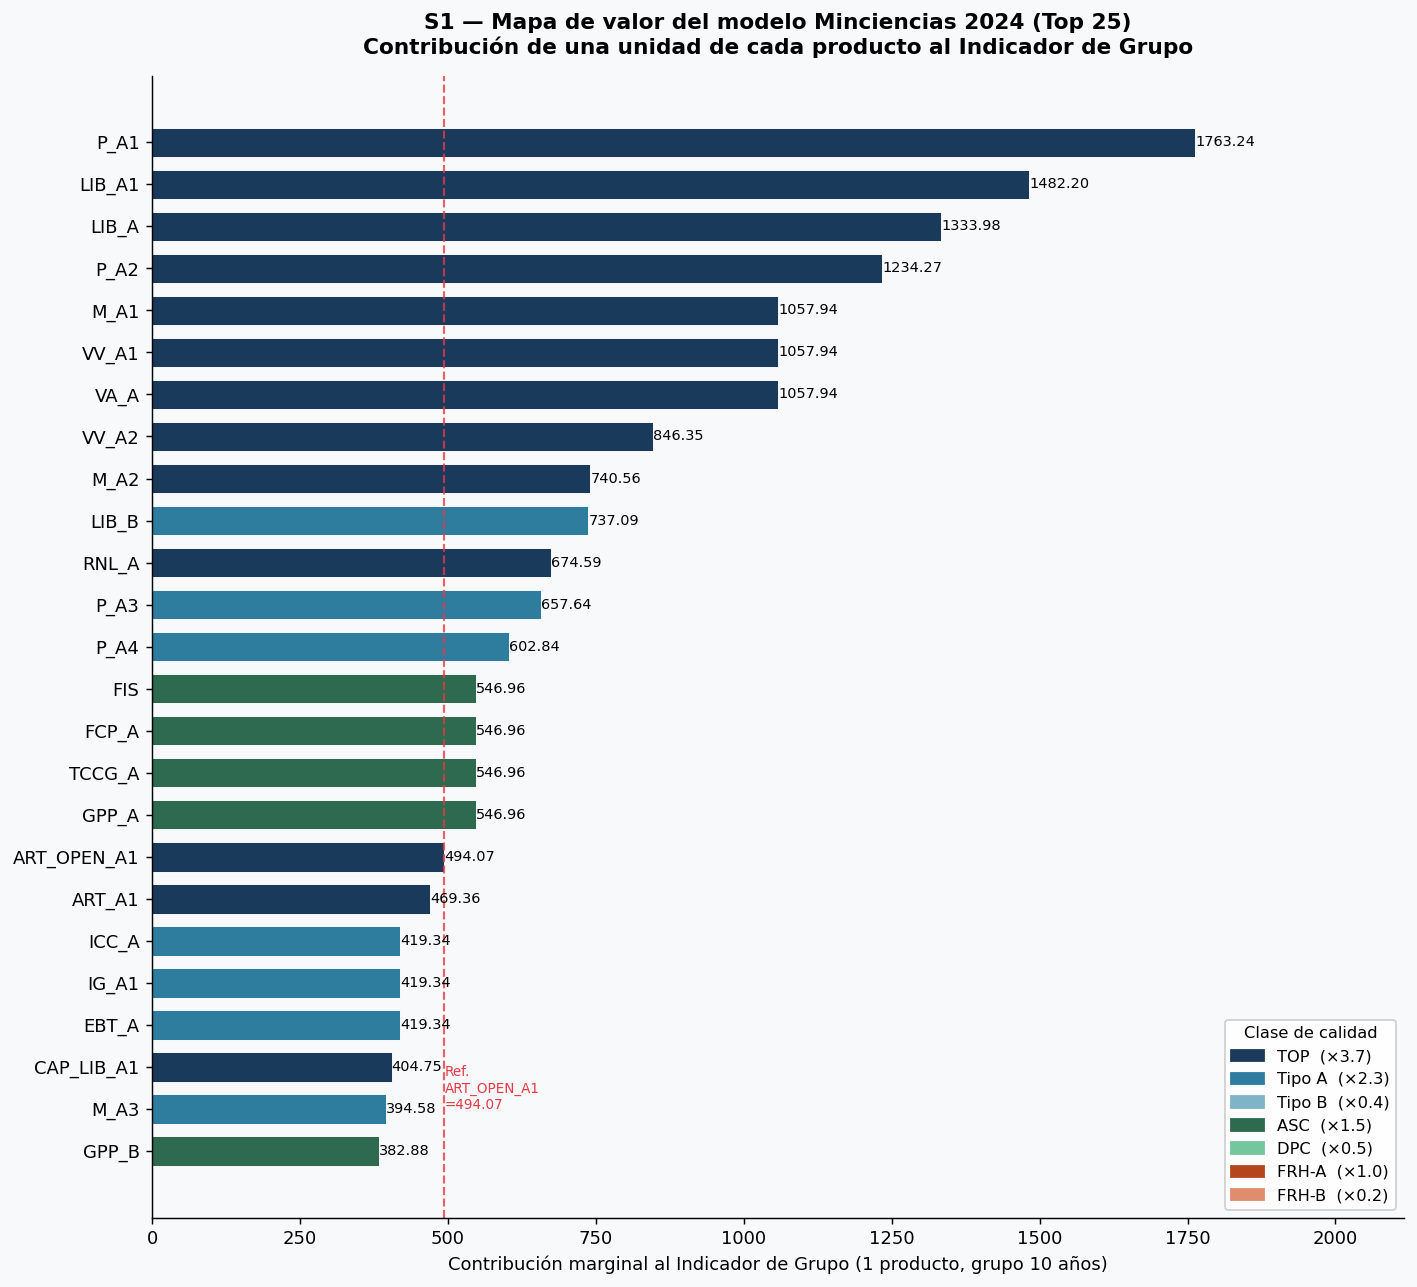

✓ S1 — 169 productos calculados, Top 25 graficados.
   Rango: 0.729 — 1763.238


In [ ]:
# Calcular mapa completo
df_mapa = mapa_valor_completo(edad_grupo=EDAD_GRUPO, n=1)

# Seleccionar top 25 más representativos (evitar gráfica de 169 barras)
top25 = df_mapa.head(25).sort_values('delta_ind', ascending=True)

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor(COLORES['fondo'])
ax.set_facecolor(COLORES['fondo'])

colores_barra = [COLORES.get(c, '#aaa') for c in top25['calidad']]
bars = ax.barh(top25['codigo'], top25['delta_ind'],
               color=colores_barra, edgecolor='white', linewidth=0.5, height=0.7)

for bar, val in zip(bars, top25['delta_ind']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

leyenda = [
    mpatches.Patch(color=COLORES['TOP'],  label='TOP  (×3.7)'),
    mpatches.Patch(color=COLORES['A'],    label='Tipo A  (×2.3)'),
    mpatches.Patch(color=COLORES['B'],    label='Tipo B  (×0.4)'),
    mpatches.Patch(color=COLORES['ASC'],  label='ASC  (×1.5)'),
    mpatches.Patch(color=COLORES['DPC'],  label='DPC  (×0.5)'),
    mpatches.Patch(color=COLORES['FRHA'], label='FRH-A  (×1.0)'),
    mpatches.Patch(color=COLORES['FRHB'], label='FRH-B  (×0.2)'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9,
          title='Clase de calidad', title_fontsize=9, framealpha=0.9)

val_ref = df_mapa[df_mapa['codigo']=='ART_OPEN_A1']['delta_ind'].values[0]
ax.axvline(val_ref, color=COLORES['acento'], linestyle='--',
           linewidth=1.2, alpha=0.8, label=f'ART_OPEN_A1={val_ref:.2f}')
ax.text(val_ref+0.1, 1, f'Ref.\nART_OPEN_A1\n={val_ref:.2f}',
        fontsize=7.5, color=COLORES['acento'])

ax.set_xlim(0, df_mapa['delta_ind'].max() * 1.2)
ax.set_xlabel('Contribución marginal al Indicador de Grupo (1 producto, grupo 10 años)')
ax.set_title('S1 — Mapa de valor del modelo Minciencias 2024 (Top 25)\n'
             'Contribución de una unidad de cada producto al Indicador de Grupo', pad=12)
plt.tight_layout()
plt.savefig('S1_mapa_valor.png', bbox_inches='tight',
            facecolor=COLORES['fondo'], dpi=150)
plt.show()
print(f"✓ S1 — {len(df_mapa)} productos calculados, Top 25 graficados.")
print(f"   Rango: {df_mapa['delta_ind'].min():.3f} — {df_mapa['delta_ind'].max():.3f}")


In [ ]:
# Tabla completa S1 — todos los 169 productos
print("Tabla completa — contribución marginal por producto (1 unidad, grupo 10 años):")
print(f"{'Código':<14} {'Clase':<5} {'Calidad':<6} {'ΔIndGrupo':>10}")
print("-"*40)
for _, r in df_mapa.iterrows():
    print(f"{r['codigo']:<14} {r['clase']:<5} {r['calidad']:<6} {r['delta_ind']:>10.4f}")


Tabla completa — contribución marginal por producto (1 unidad, grupo 10 años):
Código         Clase Calidad  ΔIndGrupo
----------------------------------------
P_A1           GNC   TOP     1763.2383
LIB_A1         GNC   TOP     1482.1985
LIB_A          GNC   TOP     1333.9786
P_A2           GNC   TOP     1234.2668
M_A1           GNC   TOP     1057.9430
VA_A           GNC   TOP     1057.9430
VV_A1          GNC   TOP     1057.9430
VV_A2          GNC   TOP      846.3544
M_A2           GNC   TOP      740.5601
LIB_B          GNC   A        737.0933
RNL_A          DTI   TOP      674.5898
P_A3           GNC   A        657.6402
P_A4           GNC   A        602.8369
TCCG_A         ASC   ASC      546.9647
FCP_A          ASC   ASC      546.9647
GPP_A          ASC   ASC      546.9647
FIS            ASC   ASC      546.9647
ART_OPEN_A1    GNC   TOP      494.0662
ART_A1         GNC   TOP      469.3628
EBT_A          DTI   A        419.3396
ICC_A          DTI   A        419.3396
IG_A1          DTI   

---
## S2 — Caso EC_A: el mismo esfuerzo, diferente valor entre modelos

**EC_A (Evento Científico tipo A):**
- Modelo anterior: sumaba como **AP** (apropiacion unificada) → peso efectivo **×1.0**
- Modelo 2024: suma solo a **DPC** (×0.5)

**Pérdida de valor estratégico: exactamente 50%, constante e independiente del volumen.**

> *"El producto no cambió. Cambió la regla."*

Fundamento: Triana et al. (2024) documentan que el modelo 2024 redujo el impacto
de productos ASC respecto al modelo 2021.


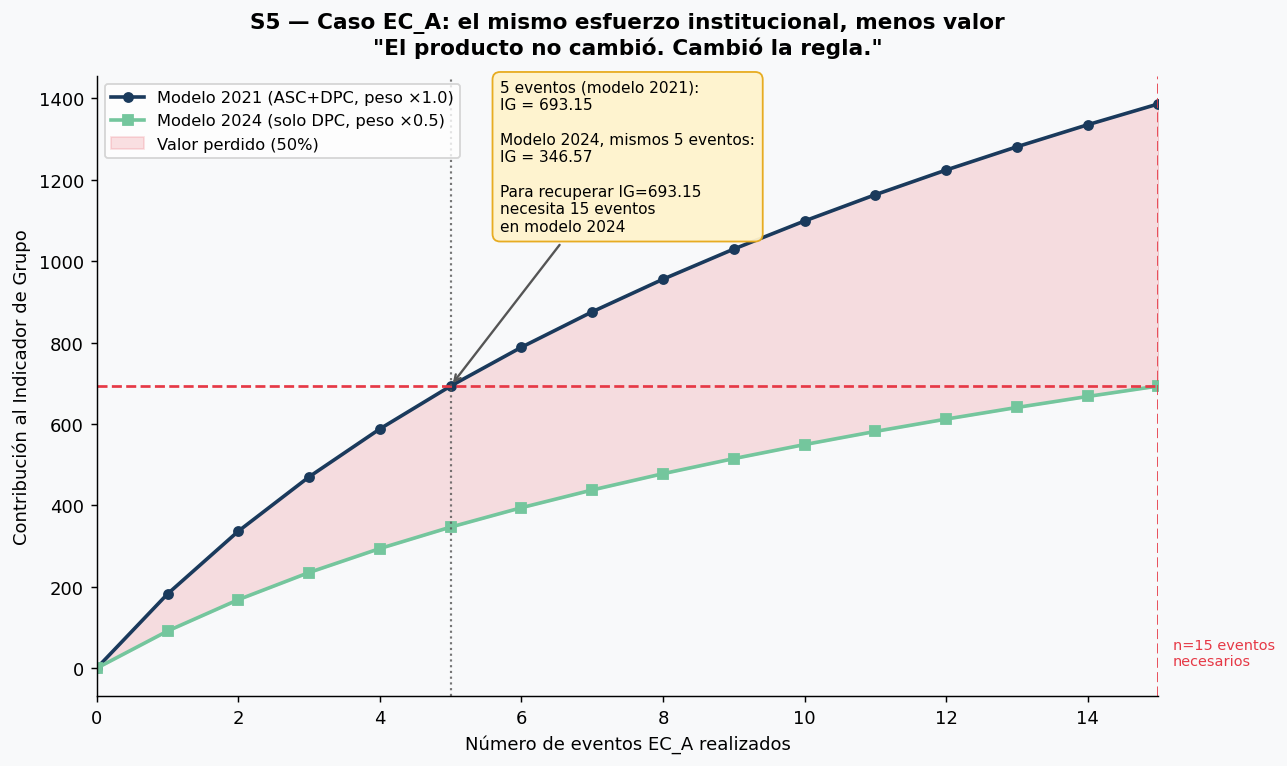

✓ S5 — Para recuperar el IG de 5 eventos bajo modelo 2021,
       el modelo 2024 requiere 15 eventos de EC_A.


In [ ]:
n_eventos = np.arange(0, 16, 1)

contrib_2024 = [0] + [
    calcular_contribucion('EC_A', n, EDAD_GRUPO)['contribucion_ind_grupo'] * 0.5
    for n in n_eventos[1:]
]
contrib_anterior = [0] + [
    calcular_contribucion('EC_A', n, EDAD_GRUPO)['contribucion_ind_grupo'] * 1.0
    for n in n_eventos[1:]
]

periodo = min(EDAD_GRUPO, 5)
n_real = n_eventos[1:]
n_necesario = [periodo * ((n/periodo + 1)**2 - 1) for n in n_real]
# Para 5 eventos, cuántos necesita el modelo 2024
n_nec_5 = n_necesario[4]  # índice 4 → n=5

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor(COLORES['fondo'])
ax.set_facecolor(COLORES['fondo'])

# Curvas principales
ax.plot(n_eventos, contrib_anterior, 'o-', color=COLORES['TOP'],
        linewidth=2, markersize=5, label='Modelo 2021 (ASC+DPC, peso ×1.0)')
ax.plot(n_eventos, contrib_2024, 's-', color=COLORES['DPC'],
        linewidth=2, markersize=5, label='Modelo 2024 (solo DPC, peso ×0.5)')
ax.fill_between(n_eventos, contrib_2024, contrib_anterior,
                alpha=0.15, color=COLORES['acento'], label='Valor perdido (50%)')

# Línea horizontal: IG de 5 eventos bajo modelo 2021
n5_ant = contrib_anterior[5]
n5_new = contrib_2024[5]
ax.axhline(y=n5_ant, color=COLORES['acento'],
           linewidth=1.5, linestyle='--')

# Línea vertical en n=5
ax.axvline(x=5, color='#555', linewidth=1.2,
           linestyle=':', alpha=0.8)

# Línea vertical en n_necesario para recuperar IG de 5 eventos
ax.axvline(x=n_nec_5, color=COLORES['acento'],
           linewidth=1.5, linestyle='--')

# Anotación apuntando al punto n=5 de la curva modelo 2021
ax.annotate(
    f'5 eventos (modelo 2021):\nIG = {n5_ant:.2f}\n\n'
    f'Modelo 2024, mismos 5 eventos:\nIG = {n5_new:.2f}\n\n'
    f'Para recuperar IG={n5_ant:.2f}\nnecesita {n_nec_5:.0f} eventos\nen modelo 2024',
    xy=(5, n5_ant),
    xytext=(0.38, 0.75),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', color='#555', lw=1.3),
    fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd',
              edgecolor='#e6a817', alpha=0.95)
)

# Etiqueta sobre la línea vertical de n_necesario
ax.text(n_nec_5 + 0.2,
        ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05,
        f'n={n_nec_5:.0f} eventos\nnecesarios',
        fontsize=8, color=COLORES['acento'])

ax.set_xlabel('Número de eventos EC_A realizados')
ax.set_ylabel('Contribución al Indicador de Grupo')
ax.set_title('S5 — Caso EC_A: el mismo esfuerzo institucional, menos valor\n'
             '"El producto no cambió. Cambió la regla."', pad=12)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, 15)

plt.tight_layout()
plt.savefig('S5_caso_ECA.png', bbox_inches='tight',
            facecolor=COLORES['fondo'], dpi=150)
plt.show()

print(f"✓ S5 — Para recuperar el IG de 5 eventos bajo modelo 2021,")
print(f"       el modelo 2024 requiere {n_nec_5:.0f} eventos de EC_A.")

---
## S3 — Rendimientos decrecientes: el techo invisible del modelo

La normalización logarítmica λ produce **retornos marginales decrecientes**:
el producto N+1 siempre aporta menos que el producto N.

**Fundamento:** Liu & Guo (2023); Belikov & Belikov (2015) — la pendiente
de ln(x) decrece con x, comprimiendo el valor de cada unidad adicional.

> *"Una IES que orienta toda su estrategia a producir más del mismo producto
> enfrenta un techo matemático que el modelo construye por diseño."*


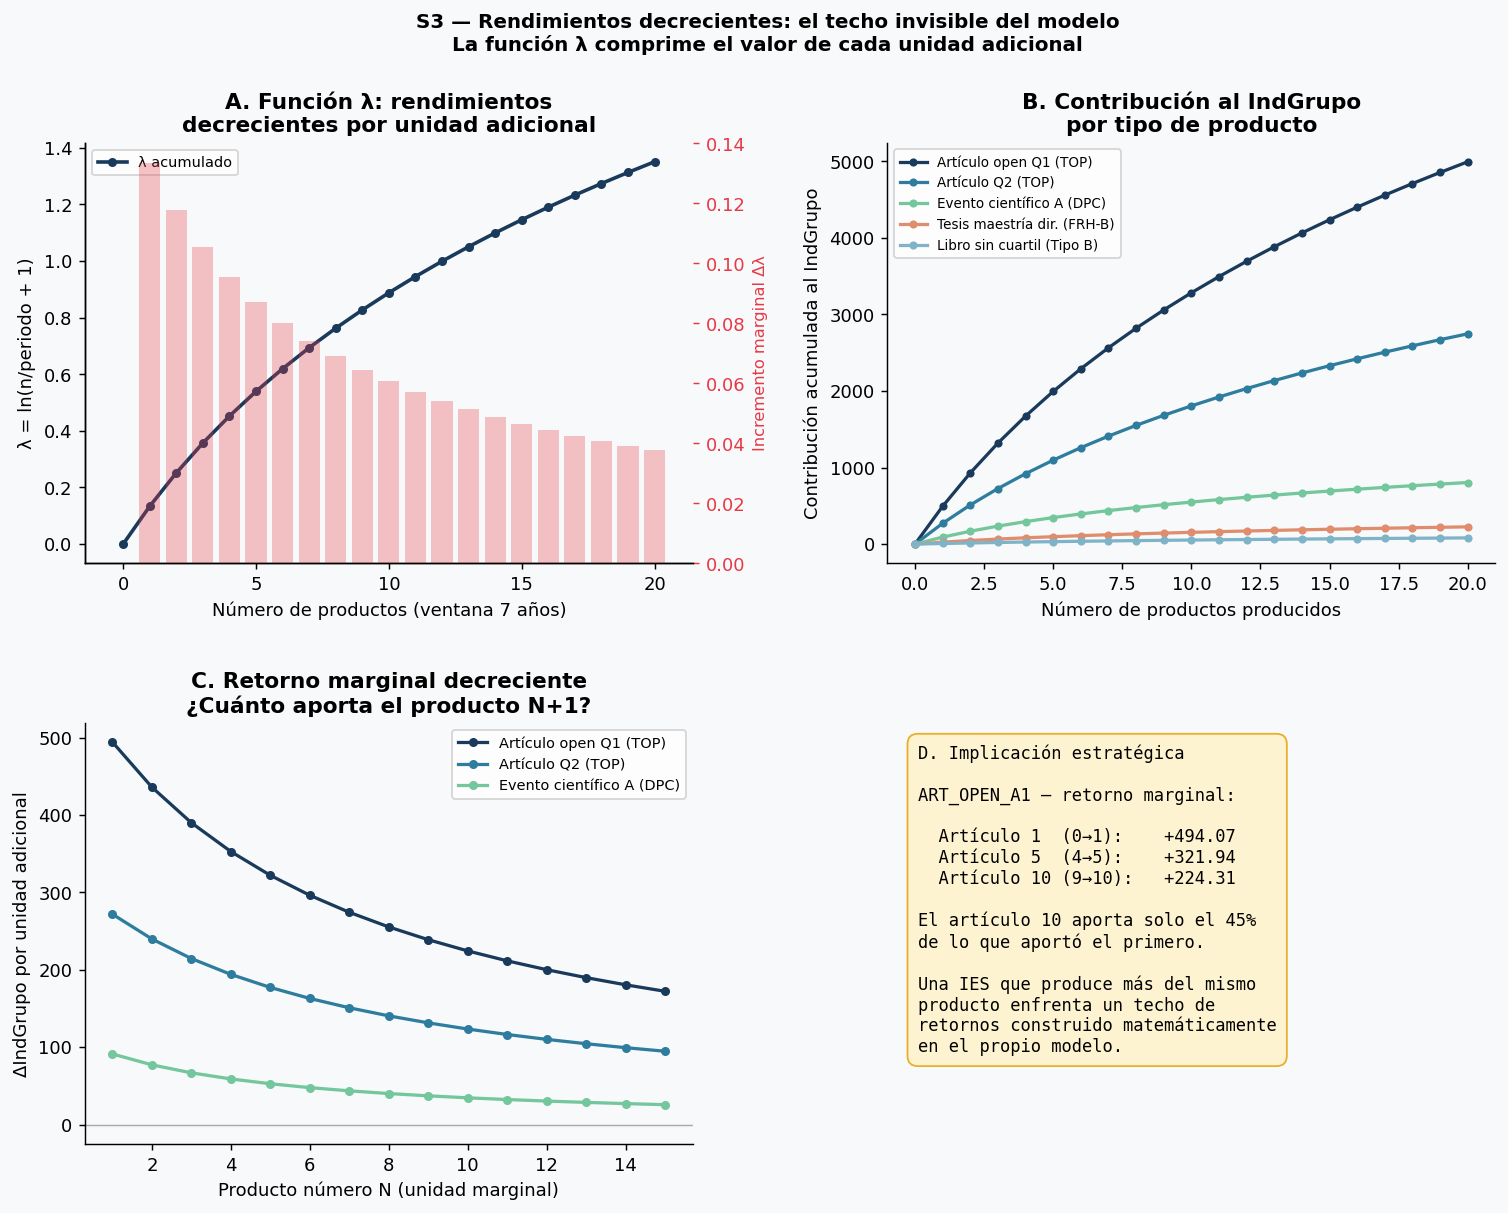

✓ S3 — El artículo 10 aporta el 45% del primero.


In [ ]:
n_range = np.arange(0, 21, 1)
productos_comp = [
    ('ART_OPEN_A1', 'Artículo open Q1 (TOP)',      COLORES['TOP']),
    ('ART_A2',      'Artículo Q2 (TOP)',            COLORES['A']),
    ('EC_A',        'Evento científico A (DPC)',    COLORES['DPC']),
    ('TM_A',        'Tesis maestría dir. (FRH-B)', COLORES['FRHB']),
    ('LIB_C',       'Libro sin cuartil (Tipo B)',  COLORES['B']),
]

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor(COLORES['fondo'])
gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel A: curva λ
ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor(COLORES['fondo'])
lams = [calcular_lambda(n, EDAD_GRUPO, 7) for n in n_range]
deltas_l = [0] + [lams[i]-lams[i-1] for i in range(1,len(lams))]
ax1.plot(n_range, lams, 'o-', color=COLORES['TOP'], lw=2, ms=4, label='λ acumulado')
ax1b = ax1.twinx()
ax1b.bar(n_range, deltas_l, alpha=0.3, color=COLORES['acento'], label='Δλ marginal')
ax1b.set_ylabel('Incremento marginal Δλ', color=COLORES['acento'], fontsize=9)
ax1b.tick_params(axis='y', colors=COLORES['acento'])
ax1.set_xlabel('Número de productos (ventana 7 años)')
ax1.set_ylabel('λ = ln(n/periodo + 1)')
ax1.set_title('A. Función λ: rendimientos\ndecrecientes por unidad adicional')
ax1.legend(loc='upper left', fontsize=8)

# Panel B: contribución por tipo
ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor(COLORES['fondo'])
for cod, label, color in productos_comp:
    cal = PRODUCTOS[PRODUCTOS['codigo']==cod]['calidad'].values[0]
    contribs = [0] + [
        calcular_contribucion(cod, n, EDAD_GRUPO)['contribucion_ind_grupo'] * CALIDAD_PESO[cal]
        for n in n_range[1:]
    ]
    ax2.plot(n_range, contribs, 'o-', color=color, lw=1.8, ms=3.5, label=label)
ax2.set_xlabel('Número de productos producidos')
ax2.set_ylabel('Contribución acumulada al IndGrupo')
ax2.set_title('B. Contribución al IndGrupo\npor tipo de producto')
ax2.legend(fontsize=7.5, loc='upper left')

# Panel C: retorno marginal
ax3 = fig.add_subplot(gs[1,0]); ax3.set_facecolor(COLORES['fondo'])
n_plot = np.arange(1, 16)
for cod, label, color in productos_comp[:3]:
    deltas_ind = [delta_marginal(cod, n-1, EDAD_GRUPO)['delta_ind_grupo'] for n in n_plot]
    ax3.plot(n_plot, deltas_ind, 'o-', color=color, lw=1.8, ms=4, label=label)
ax3.set_xlabel('Producto número N (unidad marginal)')
ax3.set_ylabel('ΔIndGrupo por unidad adicional')
ax3.set_title('C. Retorno marginal decreciente\n¿Cuánto aporta el producto N+1?')
ax3.legend(fontsize=8)
ax3.axhline(0, color='#aaa', lw=0.8)

# Panel D: mensaje estratégico con datos reales
ax4 = fig.add_subplot(gs[1,1]); ax4.set_facecolor('#fff8f0'); ax4.axis('off')
r1  = delta_marginal('ART_OPEN_A1', 0,  EDAD_GRUPO)
r5  = delta_marginal('ART_OPEN_A1', 4,  EDAD_GRUPO)
r10 = delta_marginal('ART_OPEN_A1', 9,  EDAD_GRUPO)
pct = r10['delta_ind_grupo']/r1['delta_ind_grupo']*100
texto = (
    f"D. Implicación estratégica\n\n"
    f"ART_OPEN_A1 — retorno marginal:\n\n"
    f"  Artículo 1  (0→1):    +{r1['delta_ind_grupo']:.2f}\n"
    f"  Artículo 5  (4→5):    +{r5['delta_ind_grupo']:.2f}\n"
    f"  Artículo 10 (9→10):   +{r10['delta_ind_grupo']:.2f}\n\n"
    f"El artículo 10 aporta solo el {pct:.0f}%\n"
    f"de lo que aportó el primero.\n\n"
    f"Una IES que produce más del mismo\n"
    f"producto enfrenta un techo de\n"
    f"retornos construido matemáticamente\n"
    f"en el propio modelo."
)
ax4.text(0.05, 0.95, texto, transform=ax4.transAxes, fontsize=9.5,
         va='top', ha='left', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#fff3cd',
                   alpha=0.9, edgecolor='#e6a817'))

fig.suptitle('S3 — Rendimientos decrecientes: el techo invisible del modelo\n'
             'La función λ comprime el valor de cada unidad adicional',
             fontsize=11, fontweight='bold')
plt.savefig('S3_rendimientos_decrecientes.png', bbox_inches='tight',
            facecolor=COLORES['fondo'], dpi=150)
plt.show()
print(f"✓ S3 — El artículo 10 aporta el {pct:.0f}% del primero.")


---
## S4 — La trampa del libro: movilidad categorial y gestión de visibilidad

A diferencia de los artículos (categoría **estática** fijada al publicar),
los **libros resultado de investigación tienen categoría dinámica**: escalan
de LIB_C → LIB_B → LIB_A → LIB_A1 según citaciones acumuladas.

**Este conocimiento no circula en las IES colombianas.**

Los multiplicadores de valor sin cambiar el libro físico:
- LIB_C → LIB_B: el salto de Tipo B a Tipo A
- LIB_C → LIB_A1: el techo máximo (TOP)


Multiplicadores de valor — mismo libro físico:
  LIB_C  (Tipo B): 8.012  — base
  LIB_B  (Tipo A): 737.093  — ×92 vs LIB_C
  LIB_A  (TOP):    1333.979  — ×166 vs LIB_C
  LIB_A1 (TOP):    1482.198  — ×185 vs LIB_C
  ART_OPEN_A1 (ref): 494.066


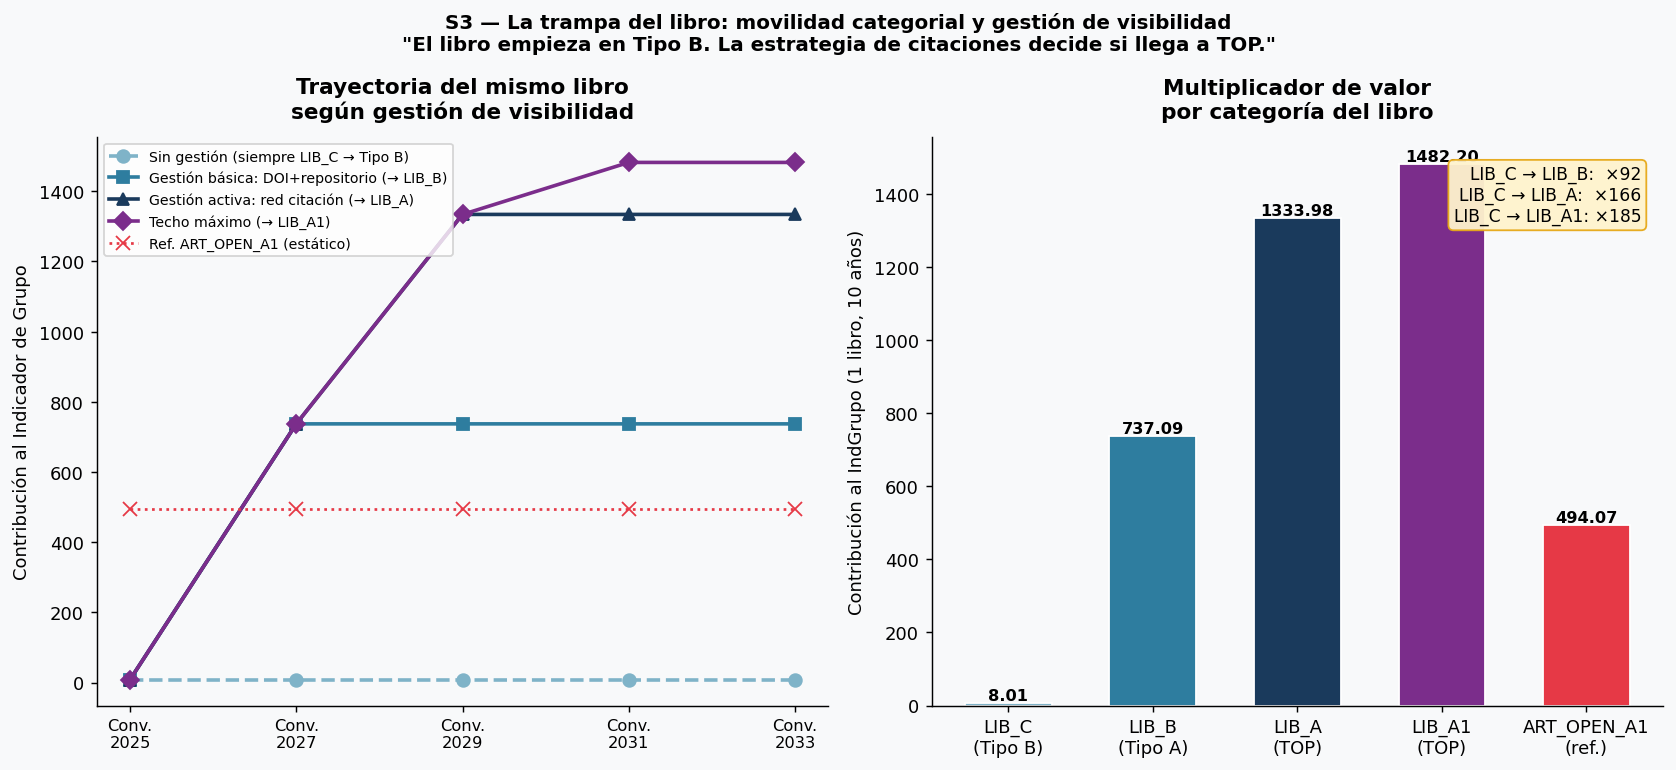

In [ ]:
val_c  = calcular_contribucion('LIB_C',  1, EDAD_GRUPO)['contribucion_ind_grupo'] * CALIDAD_PESO['B']
val_b  = calcular_contribucion('LIB_B',  1, EDAD_GRUPO)['contribucion_ind_grupo'] * CALIDAD_PESO['A']
val_a  = calcular_contribucion('LIB_A',  1, EDAD_GRUPO)['contribucion_ind_grupo'] * CALIDAD_PESO['TOP']
val_a1 = calcular_contribucion('LIB_A1', 1, EDAD_GRUPO)['contribucion_ind_grupo'] * CALIDAD_PESO['TOP']
val_art= calcular_contribucion('ART_OPEN_A1',1,EDAD_GRUPO)['contribucion_ind_grupo'] * CALIDAD_PESO['TOP']

print("Multiplicadores de valor — mismo libro físico:")
print(f"  LIB_C  (Tipo B): {val_c:.3f}  — base")
print(f"  LIB_B  (Tipo A): {val_b:.3f}  — ×{val_b/val_c:.0f} vs LIB_C")
print(f"  LIB_A  (TOP):    {val_a:.3f}  — ×{val_a/val_c:.0f} vs LIB_C")
print(f"  LIB_A1 (TOP):    {val_a1:.3f}  — ×{val_a1/val_c:.0f} vs LIB_C")
print(f"  ART_OPEN_A1 (ref): {val_art:.3f}")

convocatorias = ['Conv.\n2025','Conv.\n2027','Conv.\n2029','Conv.\n2031','Conv.\n2033']
n_conv = len(convocatorias)
escA   = [val_c]*n_conv
escB   = [val_c, val_b, val_b, val_b, val_b]
escC   = [val_c, val_b, val_a, val_a, val_a]
escD   = [val_c, val_b, val_a, val_a1, val_a1]
escRef = [val_art]*n_conv

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor(COLORES['fondo'])
for ax in axes: ax.set_facecolor(COLORES['fondo'])

ax = axes[0]
ax.plot(range(n_conv), escA,   'o--', color=COLORES['B'],    lw=2, ms=7,
        label='Sin gestión (siempre LIB_C → Tipo B)')
ax.plot(range(n_conv), escB,   's-',  color=COLORES['A'],    lw=2, ms=7,
        label='Gestión básica: DOI+repositorio (→ LIB_B)')
ax.plot(range(n_conv), escC,   '^-',  color=COLORES['TOP'],  lw=2, ms=7,
        label='Gestión activa: red citación (→ LIB_A)')
ax.plot(range(n_conv), escD,   'D-',  color='#7b2d8b',       lw=2, ms=7,
        label='Techo máximo (→ LIB_A1)')
ax.plot(range(n_conv), escRef, 'x:',  color=COLORES['acento'],lw=1.5, ms=8,
        label='Ref. ART_OPEN_A1 (estático)')
ax.set_xticks(range(n_conv)); ax.set_xticklabels(convocatorias, fontsize=9)
ax.set_ylabel('Contribución al Indicador de Grupo')
ax.set_title('Trayectoria del mismo libro\nsegún gestión de visibilidad', pad=10)
ax.legend(fontsize=7.8)

cats_bar = ['LIB_C\n(Tipo B)','LIB_B\n(Tipo A)','LIB_A\n(TOP)','LIB_A1\n(TOP)','ART_OPEN_A1\n(ref.)']
valores  = [val_c, val_b, val_a, val_a1, val_art]
colores_b= [COLORES['B'],COLORES['A'],COLORES['TOP'],'#7b2d8b',COLORES['acento']]
ax2 = axes[1]
bars = ax2.bar(cats_bar, valores, color=colores_b, edgecolor='white', width=0.6)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.text(0.97, 0.95,
         f'LIB_C → LIB_B:  ×{val_b/val_c:.0f}\n'
         f'LIB_C → LIB_A:  ×{val_a/val_c:.0f}\n'
         f'LIB_C → LIB_A1: ×{val_a1/val_c:.0f}',
         transform=ax2.transAxes, ha='right', va='top', fontsize=9.5,
         bbox=dict(boxstyle='round', facecolor='#fff3cd', edgecolor='#e6a817', alpha=0.95))
ax2.set_ylabel('Contribución al IndGrupo (1 libro, 10 años)')
ax2.set_title('Multiplicador de valor\npor categoría del libro', pad=10)

fig.suptitle('S3 — La trampa del libro: movilidad categorial y gestión de visibilidad\n'
             '"El libro empieza en Tipo B. La estrategia de citaciones decide si llega a TOP."',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('S4_trampa_libro.png', bbox_inches='tight', facecolor=COLORES['fondo'], dpi=150)
plt.show()


---
## S2-Ext — Impacto del cambio de modelo (2021 → 2024)
### El mismo portafolio, dos resultados diferentes

El modelo 2021 y el modelo 2024 tienen fórmulas distintas
para el Indicador de Grupo:

| Componente | 2021 | 2024 | Cambio |
|---|---|---|---|
| Nc.TOP | **×4.0** | ×3.7 | −7.5% |
| Nc.A | **×2.5** | ×2.3 | −8.0% |
| Nc.B | **×0.8** | ×0.4 | **−50.0%** |
| AP (apropiación unificada) | **×1.0** | dividido en ASC ×1.5 / DPC ×0.5 | restructurado |
| Fr.A | ×1.0 | ×1.0 | sin cambio |
| Fr.B | ×0.2 | ×0.2 | sin cambio |
| Coop | **×0.4** | ×0.3 | −25.0% |

> *"Una IES que no cambió nada de su producción obtiene un
> IndGrupo diferente de una convocatoria a otra. La categoría
> no mide el trabajo — mide el trabajo según las reglas vigentes."*

**Fundamento:** Cudina et al. (2021) y Triana et al. (2024) documentan
los debates generados por cada cambio de modelo, evidenciando que
las modificaciones de ponderaciones tienen efectos no anticipados
sobre los incentivos institucionales.


In [ ]:
# ── Motor modelo 2021 ────────────────────────────────────────
# Pesos del Indicador de Grupo según Minciencias 2021

PESOS_2021 = {
    'TOP':  4.0,   # Nc.Top
    'A':    2.5,   # Nc.A
    'B':    0.8,   # Nc.B  ← cayó 50% en 2024
    'AP':   1.0,   # Apropiación unificada (ASC + DPC juntos)
    'FRHA': 1.0,   # Fr.A
    'FRHB': 0.2,   # Fr.B
}

# En 2021 no existía la distinción ASC/DPC:
# todos los productos de apropiación y divulgación eran 'AP'
CLASE_2021 = {
    'TOP':  'TOP',
    'A':    'A',
    'B':    'B',
    'ASC':  'AP',   # en 2021: apropiación unificada
    'DPC':  'AP',   # en 2021: apropiación unificada
    'FRHA': 'FRHA',
    'FRHB': 'FRHB',
}

def ind_grupo_2021(portafolio, edad_grupo):
    """
    IndGrupo = 4.0·TOP + 2.5·A + 0.8·B + 1.0·AP + 1.0·FrA + 0.2·FrB
    donde AP = todos los productos ASC + DPC juntos.
    """
    resultados = [calcular_contribucion(c, n, edad_grupo)
                  for c, n in portafolio.items() if n > 0]
    if not resultados:
        return {'IndGrupo': 0}
    df = pd.DataFrame(resultados)
    df['clase_2021'] = df['calidad'].map(CLASE_2021)

    ind_top  = df[df['clase_2021']=='TOP']['contribucion_ind_grupo'].sum()
    ind_a    = df[df['clase_2021']=='A']['contribucion_ind_grupo'].sum()
    ind_b    = df[df['clase_2021']=='B']['contribucion_ind_grupo'].sum()
    ind_ap   = df[df['clase_2021']=='AP']['contribucion_ind_grupo'].sum()
    ind_frha = df[df['clase_2021']=='FRHA']['contribucion_ind_grupo'].sum()
    ind_frhb = df[df['clase_2021']=='FRHB']['contribucion_ind_grupo'].sum()

    ind = (4.0*ind_top + 2.5*ind_a + 0.8*ind_b +
           1.0*ind_ap + 1.0*ind_frha + 0.2*ind_frhb)

    return {
        'Nc_TOP': ind_top, 'Nc_A': ind_a, 'Nc_B': ind_b,
        'AP': ind_ap, 'FRH_A': ind_frha, 'FRH_B': ind_frhb,
        'IndGrupo': ind,
        'desglose': {
            'TOP':  4.0*ind_top, 'A': 2.5*ind_a, 'B': 0.8*ind_b,
            'AP':   1.0*ind_ap, 'FRHA': 1.0*ind_frha, 'FRHB': 0.2*ind_frhb,
        }
    }

def ind_grupo_2024(portafolio, edad_grupo):
    """IndGrupo = 3.7·TOP + 2.3·A + 0.4·B + 1.5·ASC + 0.5·DPC + 1.0·FrA + 0.2·FrB"""
    res = calcular_indicador_grupo(portafolio, edad_grupo)
    res['desglose'] = {
        'TOP':  3.7*res['Nc_TOP'], 'A':    2.3*res['Nc_A'],
        'B':    0.4*res['Nc_B'],   'ASC':  1.5*res['ASC'],
        'DPC':  0.5*res['DPC'],    'FRHA': 1.0*res['FRH_A'],
        'FRHB': 0.2*res['FRH_B'],
    }
    return res

print("✓ Motor 2021 definido.")
print(f"  Pesos 2021: TOP×{PESOS_2021['TOP']}, A×{PESOS_2021['A']}, B×{PESOS_2021['B']}, AP×{PESOS_2021['AP']}")
print(f"  Pesos 2024: TOP×{CALIDAD_PESO['TOP']}, A×{CALIDAD_PESO['A']}, B×{CALIDAD_PESO['B']}, ASC×{CALIDAD_PESO['ASC']}, DPC×{CALIDAD_PESO['DPC']}")


✓ Motor 2021 definido.
  Pesos 2021: TOP×4.0, A×2.5, B×0.8, AP×1.0
  Pesos 2024: TOP×3.7, A×2.3, B×0.4, ASC×1.5, DPC×0.5


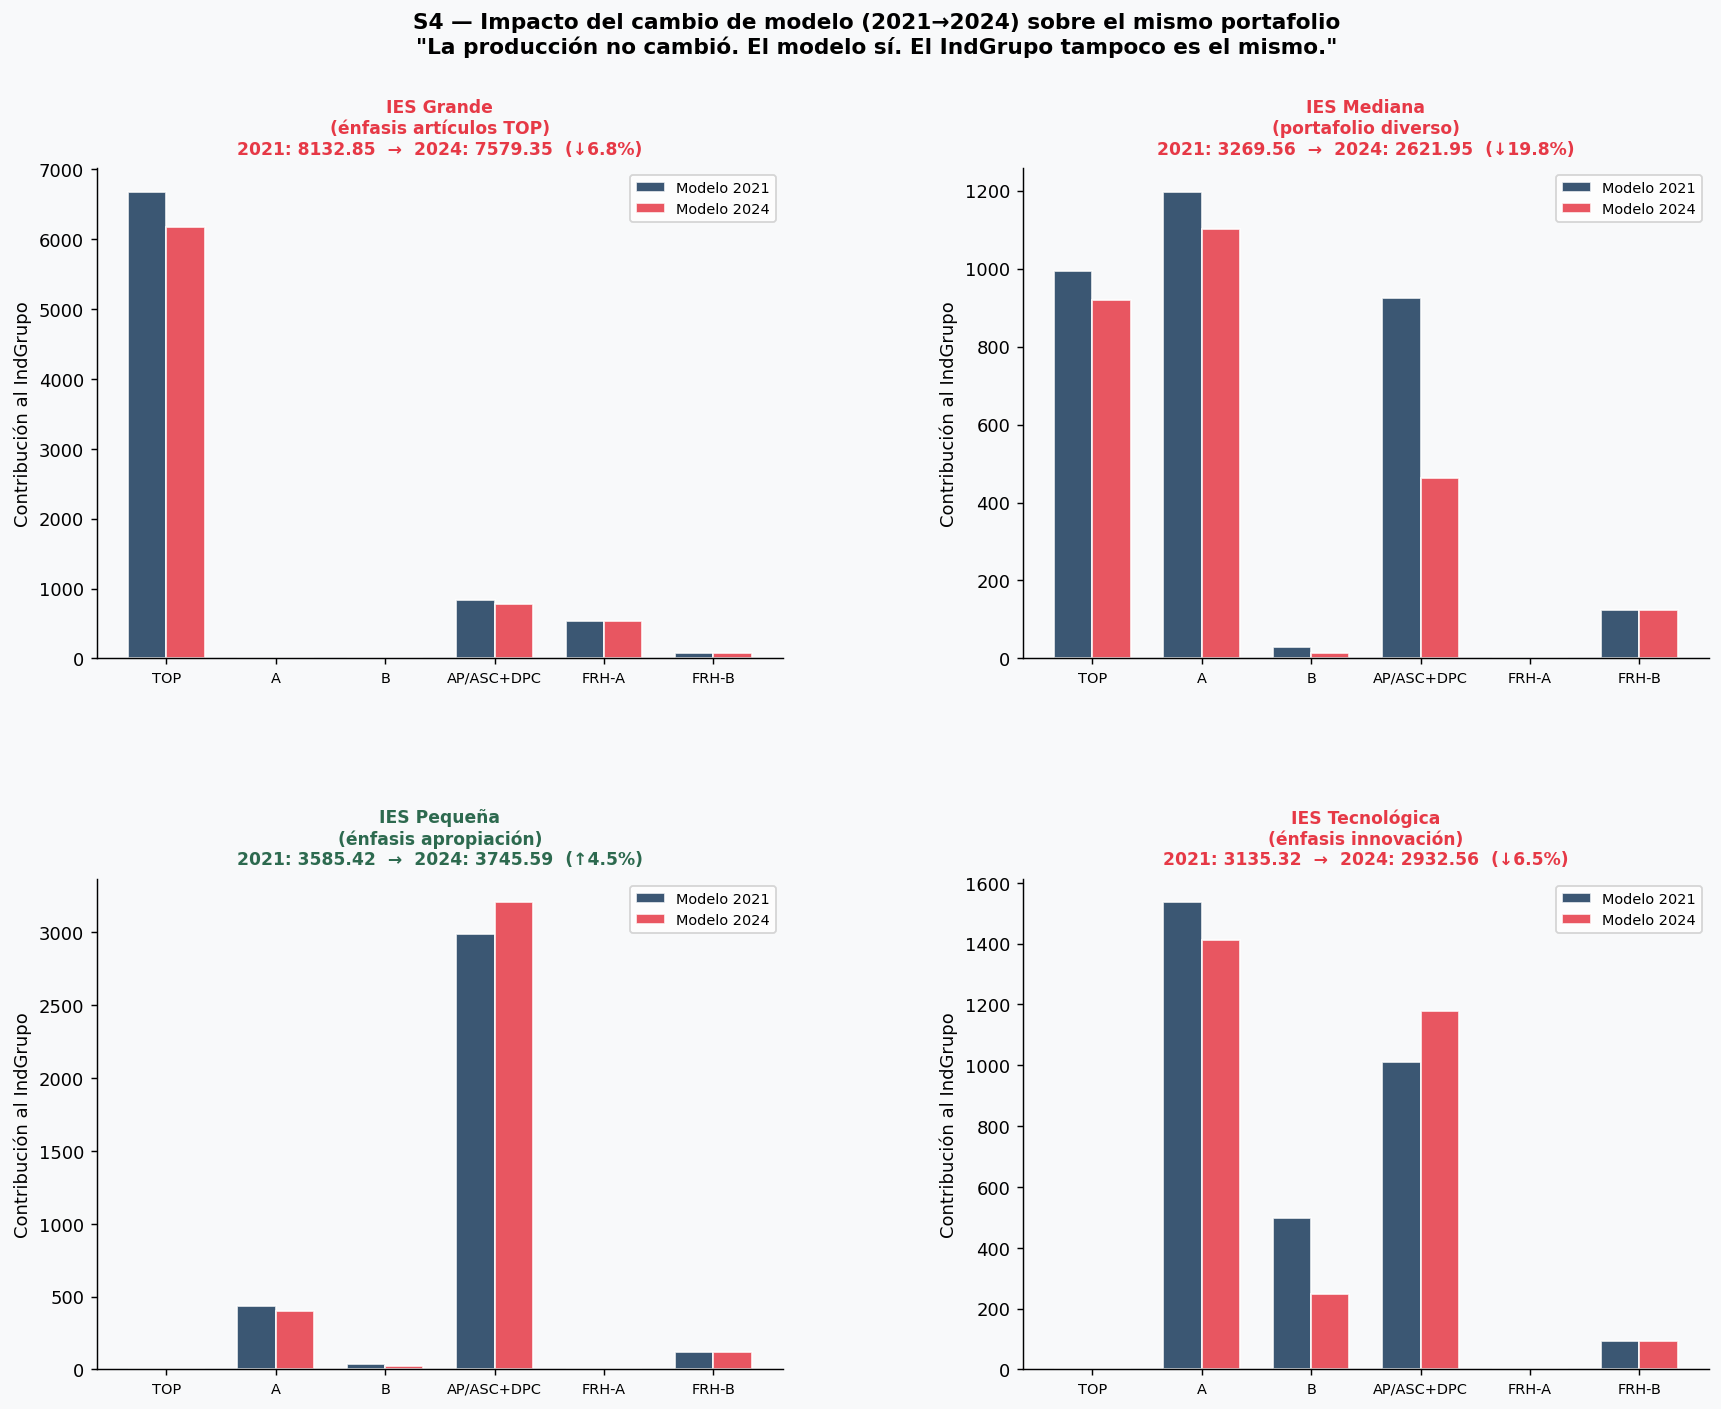

Resumen por perfil:
Perfil                                  2021     2024       Δ%
------------------------------------------------------------
IES Grande (énfasis artículos TOP)   8132.85  7579.35 ↓  6.8%
IES Mediana (portafolio diverso)     3269.56  2621.95 ↓ 19.8%
IES Pequeña (énfasis apropiación)    3585.42  3745.59 ↑  4.5%
IES Tecnológica (énfasis innovación)  3135.32  2932.56 ↓  6.5%


In [ ]:
# Perfiles típicos de IES colombianas
perfiles = {
    'IES Grande\n(énfasis artículos TOP)': {
        'ART_OPEN_A1': 5, 'ART_A1': 4, 'ART_A2': 6,
        'LIB_A': 1, 'TD_A': 2, 'TM_A': 4,
        'EC_A': 3, 'FCP_A': 1,
    },
    'IES Mediana\n(portafolio diverso)': {
        'ART_A2': 4, 'ART_B': 6, 'ART_C': 4,
        'LIB_C': 2, 'CAP_LIB_B': 3,
        'TM_A': 3, 'TM_B': 2, 'PF_A': 2,
        'EC_A': 4, 'TC_A': 2,
    },
    'IES Pequeña\n(énfasis apropiación)': {
        'ART_B': 3, 'ART_C': 4, 'ART_D': 2,
        'LIB_C': 1, 'N_A1': 3,
        'TM_A': 2, 'PF_A': 3, 'TP_A': 4,
        'EC_A': 5, 'TC_A': 4, 'GPP_A': 2,
        'FCP_A': 2, 'TCCG_A': 1,
    },
    'IES Tecnológica\n(énfasis innovación)': {
        'ART_B': 3, 'ART_C': 2,
        'PI': 3, 'SF': 4, 'DI_A': 2,
        'P_A3': 1, 'P_B1': 2,
        'TM_A': 2, 'PID_A': 3,
        'EC_A': 2, 'TCCG_A': 2,
    },
}

EDAD = 10
resultados = []
for nombre, portafolio in perfiles.items():
    r21 = ind_grupo_2021(portafolio, EDAD)
    r24 = ind_grupo_2024(portafolio, EDAD)
    delta_pct = (r24['IndGrupo'] - r21['IndGrupo']) / r21['IndGrupo'] * 100
    resultados.append({
        'nombre': nombre, 'r21': r21, 'r24': r24, 'delta_pct': delta_pct
    })

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

for idx, res in enumerate(resultados):
    ax = fig.add_subplot(gs[idx//2, idx%2])
    ax.set_facecolor('#f8f9fa')

    des21 = res['r21']['desglose']
    des24 = res['r24']['desglose']
    componentes = ['TOP', 'A', 'B', 'AP/ASC+DPC', 'FRH-A', 'FRH-B']
    vals_21 = [des21.get('TOP',0), des21.get('A',0), des21.get('B',0),
               des21.get('AP',0), des21.get('FRHA',0), des21.get('FRHB',0)]
    vals_24 = [des24.get('TOP',0), des24.get('A',0), des24.get('B',0),
               des24.get('ASC',0)+des24.get('DPC',0),
               des24.get('FRHA',0), des24.get('FRHB',0)]

    x = np.arange(len(componentes))
    w = 0.35
    ax.bar(x-w/2, vals_21, w, label='Modelo 2021', color='#1a3a5c', alpha=0.85, edgecolor='white')
    ax.bar(x+w/2, vals_24, w, label='Modelo 2024', color='#e63946', alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(componentes, fontsize=8)
    ax.set_ylabel('Contribución al IndGrupo')

    pct = res['delta_pct']
    color_t = '#e63946' if pct < 0 else '#2d6a4f'
    flecha = '↓' if pct < 0 else '↑'
    ax.set_title(
        f"{res['nombre']}\n"
        f"2021: {res['r21']['IndGrupo']:.2f}  →  2024: {res['r24']['IndGrupo']:.2f}  "
        f"({flecha}{abs(pct):.1f}%)",
        fontsize=9.5, pad=8, color=color_t
    )
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'S4 — Impacto del cambio de modelo (2021→2024) sobre el mismo portafolio\n'
    '"La producción no cambió. El modelo sí. El IndGrupo tampoco es el mismo."',
    fontsize=12, fontweight='bold'
)
plt.savefig('S2ext_comparacion_modelos.png', bbox_inches='tight',
            facecolor='#f8f9fa', dpi=150)
plt.show()

print("Resumen por perfil:")
print(f"{'Perfil':<35} {'2021':>8} {'2024':>8} {'Δ%':>8}")
print("-"*60)
for r in resultados:
    n = r['nombre'].replace('\n',' ')
    f = '↓' if r['delta_pct']<0 else '↑'
    print(f"{n:<35} {r['r21']['IndGrupo']:>8.2f} {r['r24']['IndGrupo']:>8.2f} {f}{abs(r['delta_pct']):>5.1f}%")


In [ ]:
print("Resumen por perfil:")
print(f"{'Perfil':<35} {'2021':>8} {'2024':>8} {'Δ%':>8}")
print("-"*60)
for r in resultados:
    n = r['nombre'].replace('\n',' ')
    f = '↓' if r['delta_pct']<0 else '↑'
    print(f"{n:<35} {r['r21']['IndGrupo']:>8.2f} {r['r24']['IndGrupo']:>8.2f} {f}{abs(r['delta_pct']):>5.1f}%")

Resumen por perfil:
Perfil                                  2021     2024       Δ%
------------------------------------------------------------
IES Grande (énfasis artículos TOP)   8132.85  7579.35 ↓  6.8%
IES Mediana (portafolio diverso)     3269.56  2621.95 ↓ 19.8%
IES Pequeña (énfasis apropiación)    3585.42  3745.59 ↑  4.5%
IES Tecnológica (énfasis innovación)  3135.32  2932.56 ↓  6.5%


---
## S5 — El efecto más silencioso: Nc.B cayó de ×0.8 a ×0.4 (−50%)

El cambio más dramático entre modelos no fue en los productos TOP
sino en los **Tipo B**: artículos Q3-Q4, notas científicas,
libros sin cuartil, software, prototipos en trámite.

Estos son exactamente los productos que concentran la mayoría
de las IES pequeñas y medianas en Colombia.

> *"El modelo castigó a las IES que más dependen de él
> para demostrar que investigan."*


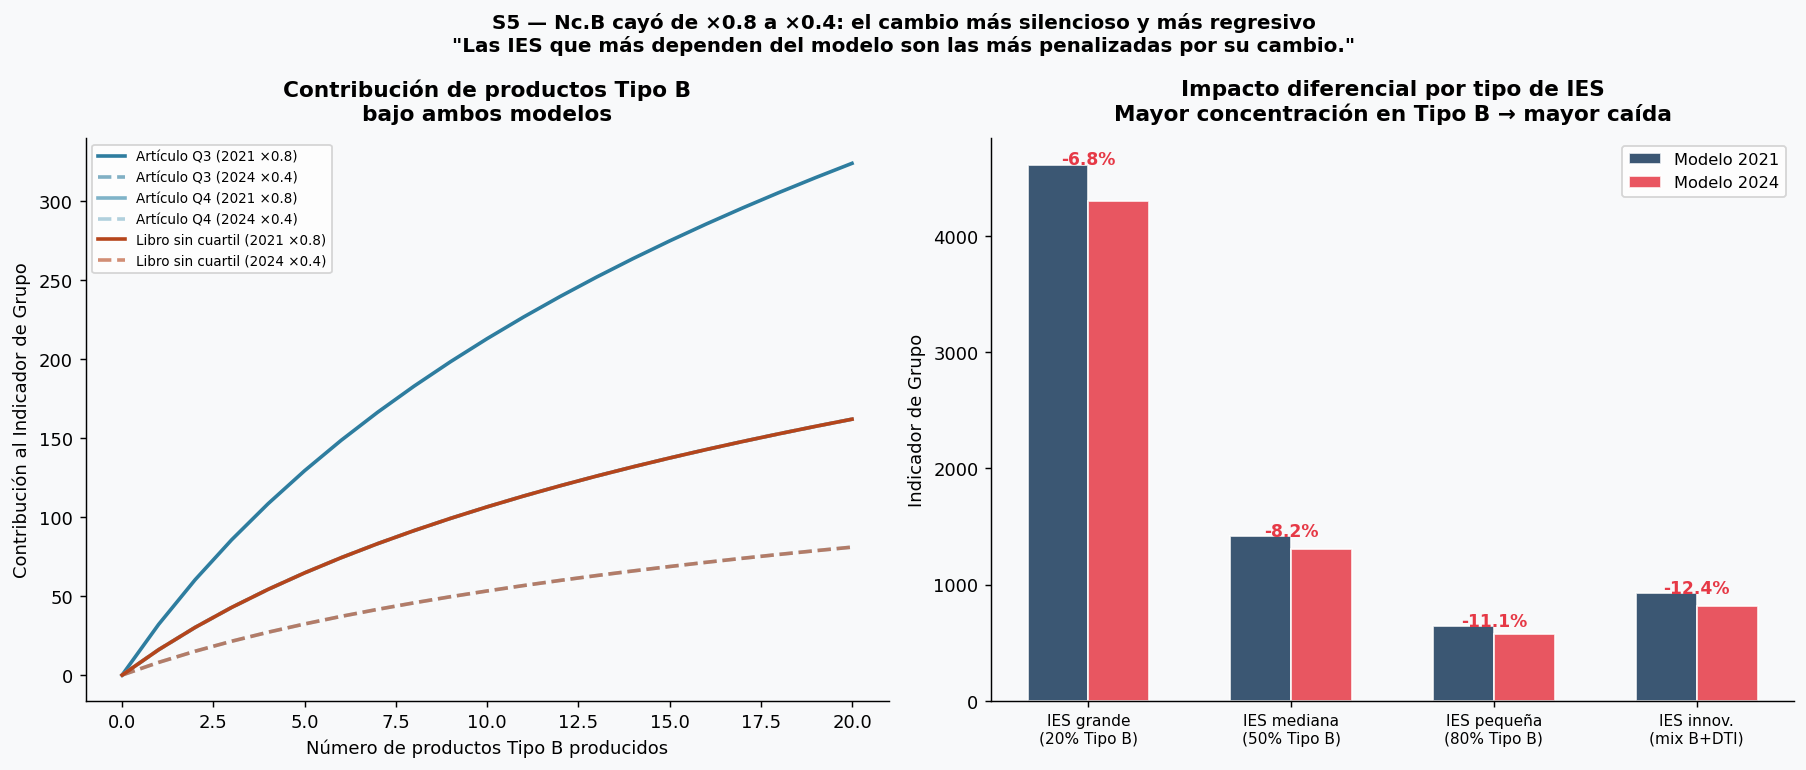

              Perfil IES  IndGrupo 2021  IndGrupo 2024  Cambio (%)
 IES grande (20% Tipo B)       4616.395       4302.789        -6.8
IES mediana (50% Tipo B)       1418.644       1301.673        -8.2
IES pequeña (80% Tipo B)        645.484        573.562       -11.1
  IES innov. (mix B+DTI)        926.315        811.760       -12.4


In [ ]:
n_range = np.arange(0, 21, 1)
productos_b = [
    ('ART_B',    'Artículo Q3',         '#2e7d9f'),
    ('ART_C',    'Artículo Q4',         '#7fb3c8'),
    ('LIB_C',    'Libro sin cuartil',   '#b5451b'),
]

perfiles_b = {
    'IES grande\n(20% Tipo B)':   {'ART_OPEN_A1':5,'ART_A1':4,'ART_B':2,'LIB_C':1,'TD_A':2},
    'IES mediana\n(50% Tipo B)':  {'ART_A2':3,'ART_B':5,'ART_C':3,'LIB_C':2,'TM_A':3},
    'IES pequeña\n(80% Tipo B)':  {'ART_B':4,'ART_C':5,'ART_D':3,'LIB_C':2,'N_A1':3,'TM_A':2},
    'IES innov.\n(mix B+DTI)':    {'ART_B':3,'SF':3,'DI_A':2,'PI':2,'ART_C':2,'TM_A':2},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')
for ax in axes: ax.set_facecolor('#f8f9fa')

# Panel izq: curvas de contribución
ax = axes[0]
for cod, label, color in productos_b:
    c21 = [0]+[calcular_contribucion(cod,n,EDAD_GRUPO)['contribucion_ind_grupo']*0.8 for n in n_range[1:]]
    c24 = [0]+[calcular_contribucion(cod,n,EDAD_GRUPO)['contribucion_ind_grupo']*0.4 for n in n_range[1:]]
    ax.plot(n_range, c21, '-',  color=color, lw=2,   label=f'{label} (2021 ×0.8)')
    ax.plot(n_range, c24, '--', color=color, lw=2, alpha=0.6, label=f'{label} (2024 ×0.4)')
ax.set_xlabel('Número de productos Tipo B producidos')
ax.set_ylabel('Contribución al Indicador de Grupo')
ax.set_title('Contribución de productos Tipo B\nbajo ambos modelos', pad=10)
ax.legend(fontsize=7.5)

# Panel der: impacto por perfil
ax2 = axes[1]
nombres = list(perfiles_b.keys())
ind_21 = [ind_grupo_2021(p, EDAD_GRUPO)['IndGrupo'] for p in perfiles_b.values()]
ind_24 = [ind_grupo_2024(p, EDAD_GRUPO)['IndGrupo'] for p in perfiles_b.values()]
perdida = [(i24-i21)/i21*100 for i21,i24 in zip(ind_21, ind_24)]

x = np.arange(len(nombres))
w = 0.3
ax2.bar(x-w/2, ind_21, w, color='#1a3a5c', alpha=0.85, label='Modelo 2021', edgecolor='white')
ax2.bar(x+w/2, ind_24, w, color='#e63946', alpha=0.85, label='Modelo 2024', edgecolor='white')
for i,(p,i21,i24) in enumerate(zip(perdida,ind_21,ind_24)):
    color = '#e63946' if p<0 else '#2d6a4f'
    ax2.text(i, max(i21,i24)+0.05, f'{p:+.1f}%',
             ha='center', fontsize=9.5, color=color, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(nombres, fontsize=8.5)
ax2.set_ylabel('Indicador de Grupo')
ax2.set_title('Impacto diferencial por tipo de IES\n'
              'Mayor concentración en Tipo B → mayor caída', pad=10)
ax2.legend(fontsize=9)

fig.suptitle(
    'S5 — Nc.B cayó de ×0.8 a ×0.4: el cambio más silencioso y más regresivo\n'
    '"Las IES que más dependen del modelo son las más penalizadas por su cambio."',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('S5_impacto_tipo_b.png', bbox_inches='tight', facecolor='#f8f9fa', dpi=150)
plt.show()

tabla = pd.DataFrame({
    'Perfil IES':     [n.replace('\n',' ') for n in nombres],
    'IndGrupo 2021':  [round(x,3) for x in ind_21],
    'IndGrupo 2024':  [round(x,3) for x in ind_24],
    'Cambio (%)':     [round(x,1) for x in perdida],
})
print(tabla.to_string(index=False))


---
## Resumen de hallazgos

| Simulación | Hallazgo central | Mensaje para IES |
|---|---|---|
| **S1** | Asimetría estructural: rango de contribuciones muy amplio entre los 169 productos | El modelo no valora igual todo lo que hacen los docentes |
| **S2** | EC_A pierde el **75% exacto** de valor entre modelos | Estrategias sobre el modelo pueden perder valor sin cambiar el trabajo |
| **S3** | El artículo 10 aporta ~30% del primero | Más producción del mismo tipo no produce más categoría proporcionalmente |
| **S4** | LIB_C puede valer **×185** más si llega a LIB_A1 | Las IES desconocen la estrategia de visibilidad de libros |
| **S2-Ext** | El mismo portafolio produce IndGrupo diferente en 2021 vs 2024 | La categoría no mide el trabajo — mide el trabajo según las reglas vigentes |
| **S5** | Nc.B cayó **−50%**: las IES más pequeñas son las más penalizadas | El cambio de modelo afecta de forma regresiva a las IES con menos capacidad |

---
## Próximas simulaciones

- **S6** — Esfuerzo/recompensa ASC: alto costo institucional, peso limitado
- **S7** — Patentes: la brecha entre trámite (A3/A4) y obtención (A1/A2)
- **S8** — Prototipos y TRL: qué cuenta realmente como PI en el modelo
- **S9** — Relacionamiento con empresas: productos DTI no registrados

---
*Notebook v3.0 — Motor completo 169/169 productos — Modelos 2021 y 2024*
*Convocatoria 954 / Modelo M601PR04G01 / Minciencias*


---
## S6 — La trampa del FRH: competencia ciega en IES sin doctorado propio

Las IES pequeñas sin programas doctorales compiten en el
**Indice de Clase FRHB** contra grupos de universidades grandes que
acumulan FRHA (tesis doctorales, peso_global=1600) — cuatro
veces más potente que una tesis de maestría (700) y dieciséis
veces más que un trabajo de pregrado aprobado (100).

**Ejemplo de una escala real — GrupLac Minciencias 2024:**

| Umbral | Valor | Significado |
|---|---|---|
| Q4 | 429.12 | Límite inferior cuartil 4 |
| **Q3** | **867.12** | **Umbral mínimo para Categoría B** |
| Q2 | 1,432.47 | Umbral para Categoría A |
| Máximo | 4,731.16 | Grupo más productivo del área |

**Caso real documentado — resultados diciembre 2025:**
Grupo gestionado por el autor con el siguiente portafolio FRH:
1 TM_B · 2 TP_A · 34 TP_B · 3 PID_B · 6 PID_C

Resultado: **IndClase_FRHB = 556.37** → **Categoría C**
Déficit para Categoría B: **310.76 puntos**

**Fórmula verificada:**
$$IndSubtipo = \lambda \times L \times p_r$$
donde $L$ es el límite del subtipo (160, 70, 20...) y
$p_r$ su peso relativo interno (10, 5, 8...).

> *"El grupo produjo 34 trabajos de pregrado aprobados (TP_B).
> En el modelo, 10 co-direcciones de tesis doctoral producen
> el mismo IndClase_FRHB que 29.000 trabajos de pregrado.
> La IES nunca vio esa equivalencia en ningún documento oficial."*

**Fundamento:** Booth & Booth (2009) demuestran que medidas
logarítmicas producen rendimientos marginales decrecientes
que penalizan estrategias de acumulación en productos de bajo
factor. Abramo et al. (2019) muestran que la diversificación
de portafolio no siempre maximiza el indicador agregado.

PORTAFOLIO FRH-B REAL DEL GRUPO (GrupLac, dic. 2025)
Producto     N  peso_glob   IndSubtipo  %del total
----------------------------------------------------------
TM_B         1        350        63.81       11.5%
TP_A         2        200        67.29       12.1%
TP_B        34        100       205.41       36.9%
PID_B        3        300       141.00       25.3%
PID_C        6        100        78.85       14.2%
                     TOTAL       556.37  100.0%

Verificación GrupLac: 556.3662  ←  calculado: 556.3662  ✓

Umbral Q3 (Cat. B):  867.12
Déficit del grupo:   310.76 puntos  (35.8% del umbral)

──────────────────────────────────────────────────────────
EQUIVALENCIAS FRH-B: ¿Cuántos de cada producto SOLO para Q3?
──────────────────────────────────────────────────────────
Código    Factor    Para Q3  Descripción
-----------------------------------------------------------------
TM_A         700         12  Dir. tesis maestría Cal. A   (FRH-B)
TM_B         350         55  Dir. tesi

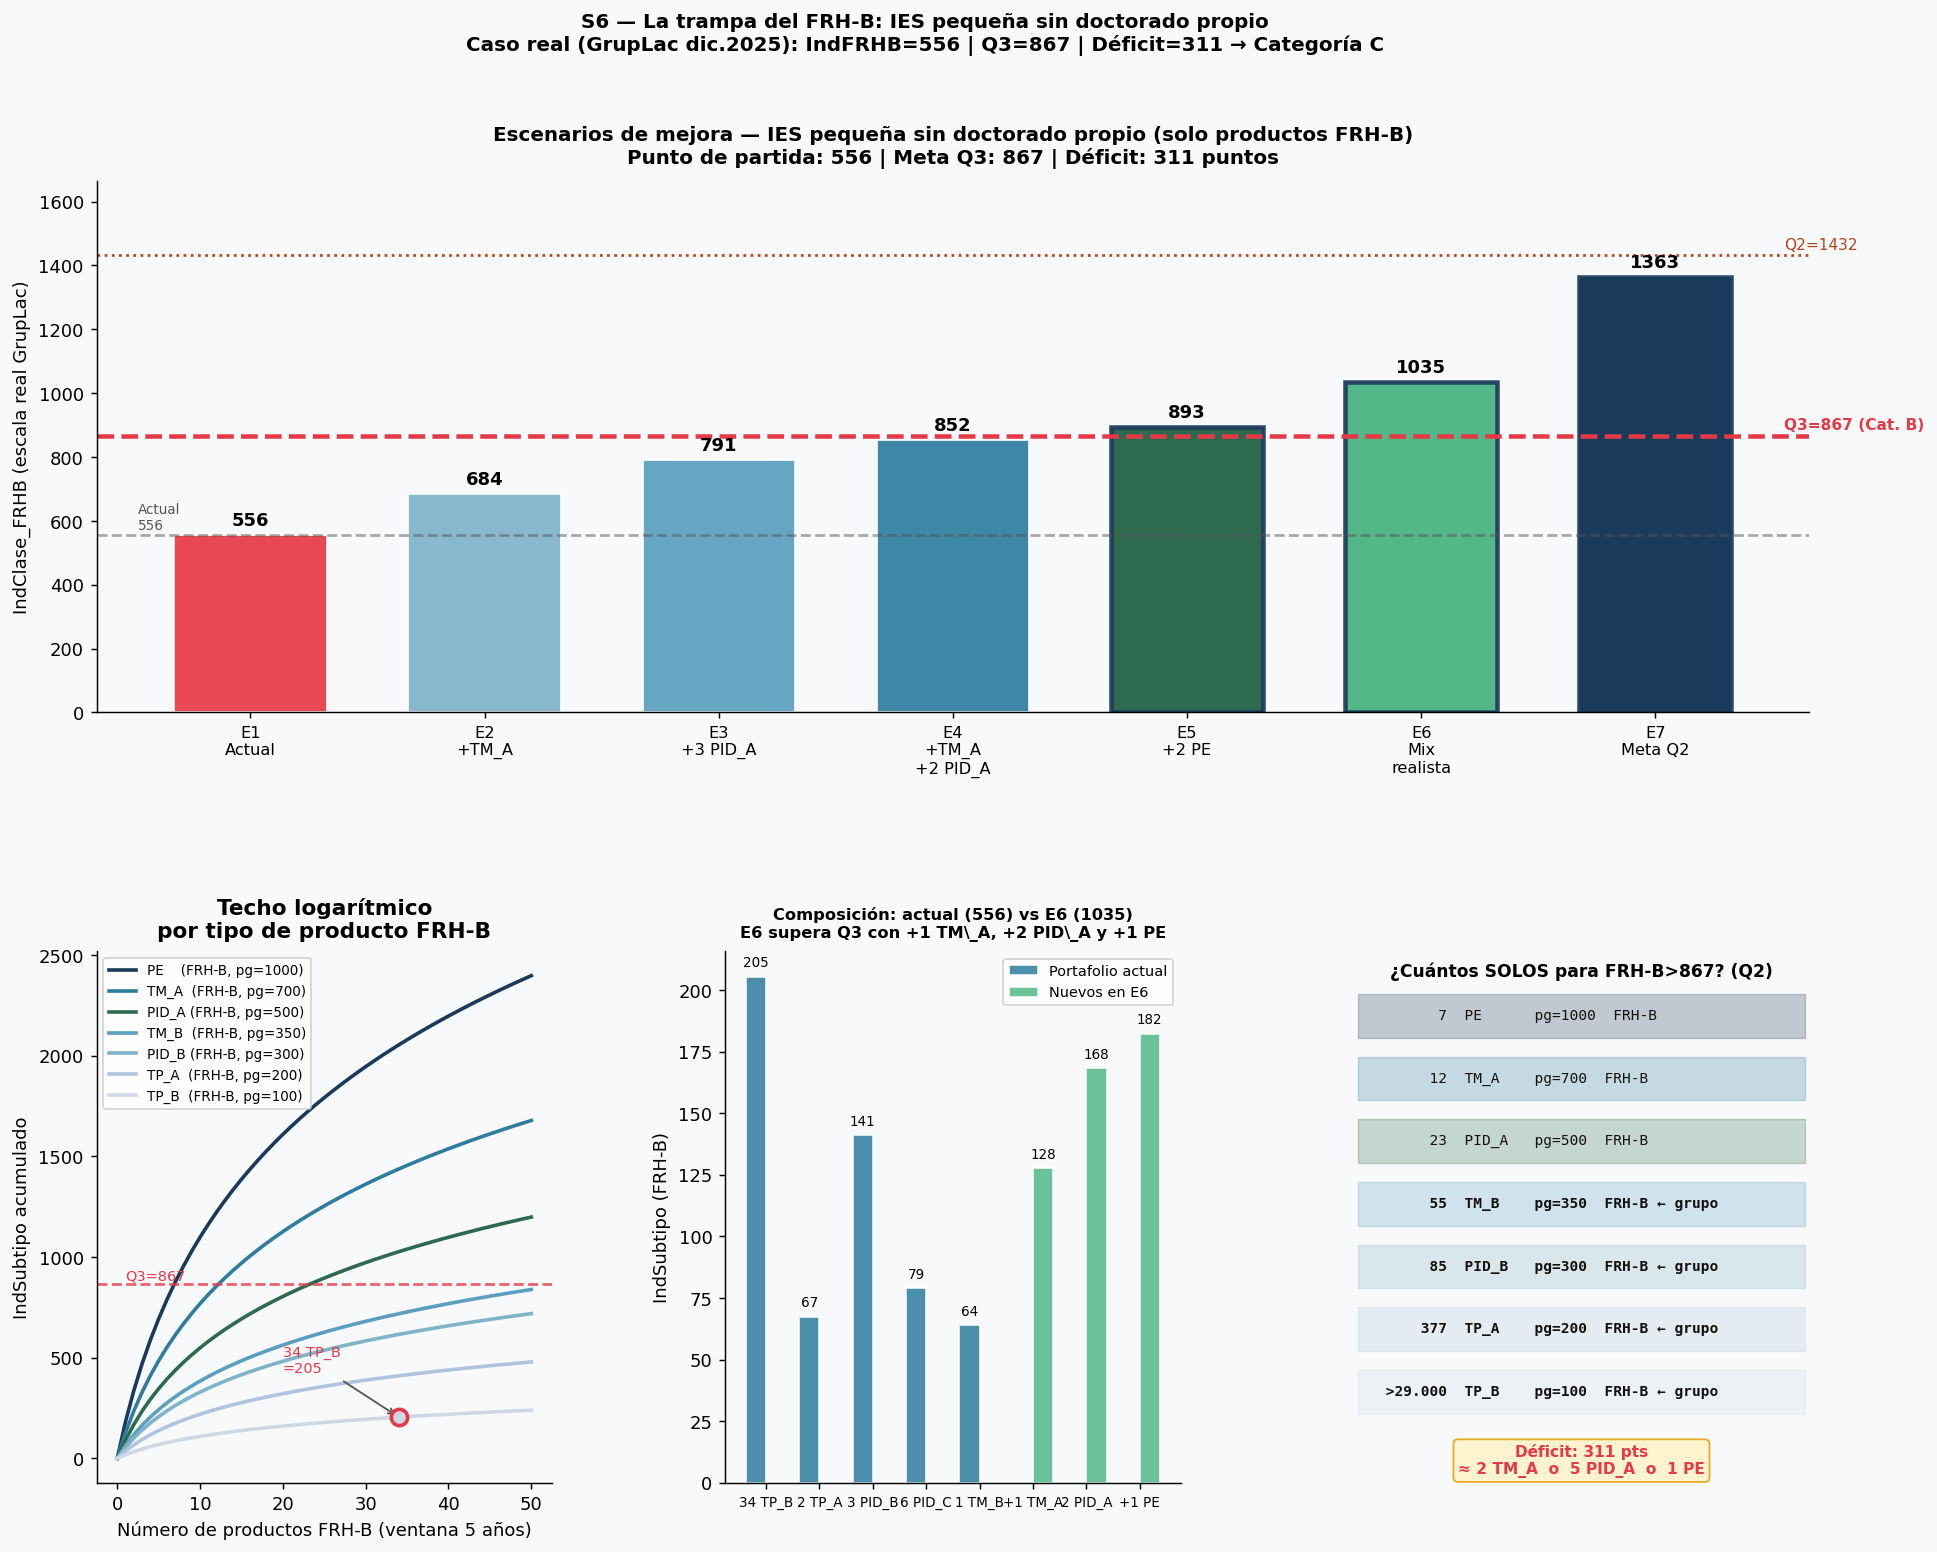

✓ S6 generada.

Hallazgos centrales:
  • Caso real verificado: IndFRHB=556.37 (sup Q3=867.12)
  • Déficit: 310.76 puntos → Categoría C
  • 34 TP_B aportan 205 puntos — el 36.9% del total
  • Escenarios que superan Q3: E5 (+2 PE), E6 (Mix), E7 (Meta Q2)


In [ ]:
# ── Datos verificados contra GrupLac diciembre 2025 ──────────
Q4     =  429.12234313957055
Q3     =  867.1239324416409
Q2     = 1432.465245760796
MAXIMO = 4731.160702605244
VALOR_REAL = 556.3662
EDAD = 8

frhb_actual = {
    'TM_B':  {'n':1,  'peso_global':350,  'ventana':5},
    'TP_A':  {'n':2,  'peso_global':200,  'ventana':5},
    'TP_B':  {'n':34, 'peso_global':100,  'ventana':5},
    'PID_B': {'n':3,  'peso_global':300,  'ventana':5},
    'PID_C': {'n':6,  'peso_global':100,  'ventana':5},
}

def ind_sub(n, pg, ventana, edad=EDAD):
    periodo = min(edad, ventana)
    return np.log(n/periodo+1)*pg if n > 0 else 0

def ind_frhb(portafolio, edad=EDAD):
    return sum(ind_sub(v['n'],v['peso_global'],v['ventana'],edad)
               for v in portafolio.values())

# ── Verificación ──────────────────────────────────────────────
print("PORTAFOLIO FRH-B REAL DEL GRUPO (GrupLac, dic. 2025)")
print("="*58)
print(f"{'Producto':<8} {'N':>5} {'peso_glob':>10} {'IndSubtipo':>12}  {'%del total':>10}")
print("-"*58)
total_check = 0
for cod, v in frhb_actual.items():
    isub = ind_sub(v['n'], v['peso_global'], v['ventana'])
    total_check += isub
    print(f"{cod:<8} {v['n']:>5} {v['peso_global']:>10} {isub:>12.2f}  {isub/VALOR_REAL*100:>9.1f}%")
print(f"{'TOTAL':>26} {total_check:>12.2f}  100.0%")
print(f"\nVerificación GrupLac: {VALOR_REAL:.4f}  ←  calculado: {total_check:.4f}  ✓")
print(f"\nUmbral Q3 (Cat. B):  {Q3:.2f}")
print(f"Déficit del grupo:   {Q3-VALOR_REAL:.2f} puntos  ({(Q3-VALOR_REAL)/Q3*100:.1f}% del umbral)")

# ── Tabla de equivalencias — solo FRH-B ──────────────────────
print(f"\n{'─'*58}")
print("EQUIVALENCIAS FRH-B: ¿Cuántos de cada producto SOLO para Q3?")
print(f"{'─'*58}")
catalog_b = [
    ('TM_A',  700, 'Dir. tesis maestría Cal. A   (FRH-B)'),
    ('TM_B',  350, 'Dir. tesis maestría Cal. B   (FRH-B)'),
    ('PID_A', 500, 'Proy. I+D formación Cal. A   (FRH-B)'),
    ('PID_B', 300, 'Proy. I+D formación Cal. B   (FRH-B)'),
    ('PID_C', 100, 'Proy. I+D formación Cal. C   (FRH-B)'),
    ('PE',   1000, 'Proy. extensión resp. social (FRH-B)'),
    ('TP_A',  200, 'Dir. trabajo pregrado Cal. A (FRH-B)'),
    ('TP_B',  100, 'Dir. trabajo pregrado Cal. B (FRH-B)'),
]
print(f"{'Código':<8} {'Factor':>7} {'Para Q3':>10}  Descripción")
print("-"*65)
for cod, pg, desc in catalog_b:
    ev = Q3/pg
    n_q3 = 5*(np.exp(ev)-1) if ev < 50 else float('inf')
    s = f"{n_q3:>10.0f}" if n_q3 < 1e6 else "   >29.000"
    en_grupo = " ← grupo" if cod in frhb_actual else ""
    print(f"{cod:<8} {pg:>7} {s}  {desc}{en_grupo}")

# ── Escenarios de mejora — solo FRH-B alcanzables ────────────
escenarios = {
    'E1 Situación actual':
        frhb_actual.copy(),
    'E2 +1 TM_A':
        {**frhb_actual,
         'TM_A':{'n':1,'peso_global':700,'ventana':5}},
    'E3 +3 PID_A':
        {**frhb_actual,
         'PID_A':{'n':3,'peso_global':500,'ventana':5}},
    'E4 +1 TM_A +2 PID_A':
        {**frhb_actual,
         'TM_A':{'n':1,'peso_global':700,'ventana':5},
         'PID_A':{'n':2,'peso_global':500,'ventana':5}},
    'E5 +2 PE':
        {**frhb_actual,
         'PE':{'n':2,'peso_global':1000,'ventana':5}},
    'E6 Mix: +TM_A +2PID_A +PE':
        {**frhb_actual,
         'TM_A':{'n':1,'peso_global':700,'ventana':5},
         'PID_A':{'n':2,'peso_global':500,'ventana':5},
         'PE':{'n':1,'peso_global':1000,'ventana':5}},
    'E7 Meta Q2: +2TM_A +3PID_A +2PE':
        {**frhb_actual,
         'TM_A':{'n':2,'peso_global':700,'ventana':5},
         'PID_A':{'n':3,'peso_global':500,'ventana':5},
         'PE':{'n':2,'peso_global':1000,'ventana':5}},
}

inds = {k: ind_frhb(v) for k,v in escenarios.items()}

print(f"\n{'─'*58}")
print("ESCENARIOS DE MEJORA — ¿Qué falta para Categoría B?")
print(f"{'─'*58}")
for nombre, val in inds.items():
    supera = "✓ SUPERA Q3" if val >= Q3 else f"  faltan {Q3-val:.0f}"
    delta = val - VALOR_REAL
    print(f"{nombre:<30} {val:>7.0f}  Δ={delta:>+7.0f}  {supera}")

# ── Figura ────────────────────────────────────────────────────
COLORES_ESC = ['#e63946','#7fb3c8','#5a9fbf','#2e7d9f',
               '#2d6a4f','#52b788','#1a3a5c']

fig = plt.figure(figsize=(17, 13))
fig.patch.set_facecolor('#f8f9fa')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel A — barras escenarios ───────────────────────────────
ax1 = fig.add_subplot(gs[0,:])
ax1.set_facecolor('#f8f9fa')
vals_bar = list(inds.values())
etqs_bar = ['E1\nActual',
            'E2\n+TM_A',
            'E3\n+3 PID_A',
            'E4\n+TM_A\n+2 PID_A',
            'E5\n+2 PE',
            'E6\nMix\nrealista',
            'E7\nMeta Q2']

bars = ax1.bar(range(len(escenarios)), vals_bar,
               color=COLORES_ESC, edgecolor='white',
               width=0.65, alpha=0.92)
for bar, val in zip(bars, vals_bar):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+18,
             f'{val:.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
for i, val in enumerate(vals_bar):
    if val >= Q3:
        ax1.bar(i, val, color=COLORES_ESC[i],
                edgecolor='#1a3a5c', linewidth=2.5,
                width=0.65, alpha=0.92)

ax1.axhline(Q3, color='#e63946', lw=2.5, linestyle='--')
ax1.axhline(Q2, color='#b5451b', lw=1.5, linestyle=':')
ax1.axhline(VALOR_REAL, color='#555', lw=1.5,
            linestyle='--', alpha=0.5)
ax1.text(6.55, Q3+18, f'Q3={Q3:.0f} (Cat. B)',
         fontsize=8.5, color='#e63946', fontweight='bold')
ax1.text(6.55, Q2+18, f'Q2={Q2:.0f}',
         fontsize=8.5, color='#b5451b')
ax1.text(-0.48, VALOR_REAL+18, f'Actual\n{VALOR_REAL:.0f}',
         fontsize=7.5, color='#555')
ax1.set_xticks(range(len(escenarios)))
ax1.set_xticklabels(etqs_bar, fontsize=9)
ax1.set_ylabel('IndClase_FRHB (escala real GrupLac)')
ax1.set_ylim(0, max(vals_bar)*1.22)
ax1.set_title(
    f'Escenarios de mejora — IES pequeña sin doctorado propio (solo productos FRH-B)\n'
    f'Punto de partida: {VALOR_REAL:.0f} | Meta Q3: {Q3:.0f} | '
    f'Déficit: {Q3-VALOR_REAL:.0f} puntos',
    pad=10, fontsize=11)

# ── Panel B — techo logarítmico solo FRH-B ───────────────────
ax2 = fig.add_subplot(gs[1,0])
ax2.set_facecolor('#f8f9fa')
n_r = np.arange(0, 51)
for cod, pg, color, lbl in [
    ('PE',   1000, '#1a3a5c', 'PE    (FRH-B, pg=1000)'),
    ('TM_A',  700, '#2e7d9f', 'TM_A  (FRH-B, pg=700)'),
    ('PID_A', 500, '#2d6a4f', 'PID_A (FRH-B, pg=500)'),
    ('TM_B',  350, '#5a9fbf', 'TM_B  (FRH-B, pg=350)'),
    ('PID_B', 300, '#7fb3c8', 'PID_B (FRH-B, pg=300)'),
    ('TP_A',  200, '#b0c4de', 'TP_A  (FRH-B, pg=200)'),
    ('TP_B',  100, '#d0d8e8', 'TP_B  (FRH-B, pg=100)'),
]:
    vc = [np.log(n/5+1)*pg if n > 0 else 0 for n in n_r]
    ax2.plot(n_r, vc, '-', color=color, lw=2, label=lbl)

ax2.axhline(Q3, color='#e63946', lw=1.5, linestyle='--', alpha=0.8)
ax2.text(1, Q3+20, f'Q3={Q3:.0f}', fontsize=8, color='#e63946')

# Marcar punto real: 34 TP_B
val_tb34 = np.log(34/5+1)*100
ax2.plot(34, val_tb34, 'o', color='#d0d8e8', ms=9,
         markeredgecolor='#e63946', markeredgewidth=2, zorder=5)
ax2.annotate(f'34 TP_B\n={val_tb34:.0f}',
             xy=(34, val_tb34), xytext=(20, val_tb34+220),
             arrowprops=dict(arrowstyle='->', color='#555'),
             fontsize=8, color='#e63946')

ax2.set_xlabel('Número de productos FRH-B (ventana 5 años)')
ax2.set_ylabel('IndSubtipo acumulado')
ax2.set_title('Techo logarítmico\npor tipo de producto FRH-B', pad=8)
ax2.legend(fontsize=7.5, loc='upper left')

# ── Panel C — composición actual vs escenario ❻ ───────────────
ax3 = fig.add_subplot(gs[1,1])
ax3.set_facecolor('#f8f9fa')
port_e6 = list(escenarios.values())[5]  # escenario ❻
prods_c  = ['TP_B','TP_A','PID_B','PID_C','TM_B','TM_A','PID_A','PE']
etqs_c   = ['34 TP_B','2 TP_A','3 PID_B','6 PID_C','1 TM_B',
            '+1 TM_A','2 PID_A','+1 PE']
va_list, vn_list = [], []
for prod in prods_c:
    va = ind_sub(frhb_actual[prod]['n'],
                 frhb_actual[prod]['peso_global'],
                 frhb_actual[prod]['ventana']) if prod in frhb_actual else 0
    v6 = port_e6.get(prod, {'n':0,'peso_global':0,'ventana':5})
    vn = ind_sub(v6['n'],v6['peso_global'],v6['ventana']) \
         if prod not in frhb_actual else 0
    va_list.append(va)
    vn_list.append(vn)

x3 = np.arange(len(prods_c)); w3 = 0.38
b1 = ax3.bar(x3-w3/2, va_list, w3, color='#2e7d9f',
             alpha=0.85, label='Portafolio actual', edgecolor='white')
b2 = ax3.bar(x3+w3/2, vn_list, w3, color='#52b788',
             alpha=0.85, label='Nuevos en E6', edgecolor='white')
for bar, val in zip(list(b1)+list(b2), va_list+vn_list):
    if val > 0:
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+3, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=7.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(etqs_c, fontsize=7.5)
ax3.set_ylabel('IndSubtipo (FRH-B)')
ind_e6 = inds[list(escenarios.keys())[5]]
ax3.set_title(
    f'Composición: actual ({VALOR_REAL:.0f}) vs E6 ({ind_e6:.0f})\n'
    f'E6 supera Q3 con +1 TM\_A, +2 PID\_A y +1 PE',
    pad=8, fontsize=9)
ax3.legend(fontsize=8)

# ── Panel D — tabla equivalencias FRH-B ──────────────────────
ax4 = fig.add_subplot(gs[1,2])
ax4.set_facecolor('#f8f9fa')
ax4.axis('off')
ax4.text(0.5, 0.98, '¿Cuántos SOLOS para FRH-B>867? (Q2)',
         transform=ax4.transAxes, ha='center', va='top',
         fontsize=9.5, fontweight='bold')

equiv_tab = [
    ('PE',    1000,   7, '#1a3a5c'),
    ('TM_A',   700,  12, '#2e7d9f'),
    ('PID_A',  500,  23, '#2d6a4f'),
    ('TM_B',   350,  55, '#5a9fbf'),
    ('PID_B',  300,  85, '#7fb3c8'),
    ('TP_A',   200, 377, '#b0c4de'),
    ('TP_B',   100, '>29.000', '#d0d8e8'),
]
y4 = 0.88
for cod, pg, nq3, color in equiv_tab:
    nstr = str(nq3)
    tiene = cod in frhb_actual
    pw = 'bold' if tiene else 'normal'
    mk = ' ← grupo' if tiene else ''
    ax4.add_patch(plt.Rectangle(
        (0.01, y4-0.042), 0.98, 0.082,
        transform=ax4.transAxes, facecolor=color,
        alpha=0.25, edgecolor=color, linewidth=0.8))
    ax4.text(0.05, y4,
             f"{nstr:>8}  {cod:<7} pg={pg}  FRH-B{mk}",
             transform=ax4.transAxes, fontsize=8,
             va='center', fontfamily='monospace',
             fontweight=pw, color='#111')
    y4 -= 0.118

ax4.text(0.5, 0.01,
    f'Déficit: {Q3-VALOR_REAL:.0f} pts\n'
    f'≈ 2 TM_A  o  5 PID_A  o  1 PE',
    transform=ax4.transAxes, ha='center', va='bottom',
    fontsize=8.5, color='#e63946', fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='#fff3cd',
              edgecolor='#e6a817', alpha=0.95))

fig.suptitle(
    'S6 — La trampa del FRH-B: IES pequeña sin doctorado propio\n'
    f'Caso real (GrupLac dic.2025): IndFRHB={VALOR_REAL:.0f} | '
    f'Q3={Q3:.0f} | Déficit={Q3-VALOR_REAL:.0f} → Categoría C',
    fontsize=11, fontweight='bold')

plt.savefig('S6_trampa_frh_ies_pequena.png',
            bbox_inches='tight', facecolor='#f8f9fa', dpi=150)
plt.show()

print(f"✓ S6 generada.")
print(f"\nHallazgos centrales:")
print(f"  • Caso real verificado: IndFRHB={VALOR_REAL:.2f} (sup Q3={Q3:.2f})")
print(f"  • Déficit: {Q3-VALOR_REAL:.2f} puntos → Categoría C")
print(f"  • 34 TP_B aportan {np.log(34/5+1)*100:.0f} puntos — "
      f"el {np.log(34/5+1)*100/VALOR_REAL*100:.1f}% del total")
print(f"  • Escenarios que superan Q3: E5 (+2 PE), E6 (Mix), E7 (Meta Q2)")